In [1]:
from google.cloud import bigquery

client = bigquery.Client(project="deneme-505002")

df = client.query("""
    select count(*) as n_rows
    from `deneme-505002.instacart_features.training_set`
""").to_dataframe()

print(df)

/Users/cemkulekci/anaconda3/lib/python3.11/site-packages/google/auth/_default.py:76: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
/Users/cemkulekci/anaconda3/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


    n_rows
0  8474661


In [2]:
import os
from google.cloud import bigquery
import pyarrow.parquet as pq

PATH = "training_set.parquet"

if os.path.exists(PATH):
    print(f"{PATH} It already exists; download skipped..")
else:
    client = bigquery.Client(project="deneme-505002")
    job = client.query("""
        select * from `deneme-505002.instacart_features.training_set`
    """)

    batches = job.result().to_arrow_iterable()
    first = next(batches)

    writer = pq.ParquetWriter(PATH + ".tmp", first.schema, compression="snappy")
    writer.write_batch(first)

    n = first.num_rows
    for batch in batches:
        writer.write_batch(batch)
        n += batch.num_rows
        if n % 1_000_000 < batch.num_rows:
            print(f"{n:,} line written")

    writer.close()
    os.rename(PATH + ".tmp", PATH)
    print(f"finished: {n:,} line")

training_set.parquet It already exists; download skipped..


In [3]:
import os
print(os.path.getsize("training_set.parquet") / 1e6, "MB")

884.419098 MB


In [4]:
import pyarrow.parquet as pq

pf = pq.ParquetFile("training_set.parquet")
print(pf.metadata.num_rows, "rows")
print(pf.metadata.num_columns, "columns")

8474661 rows
53 columns


In [5]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import lightgbm as lgb
import time
import sklearn

from src.metrics import user_f1, user_precision_recall, evaluation_report
from google.cloud import bigquery
from sklearn.metrics import roc_auc_score
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from src.data_loader import load_training_set, list_columns, memory_report
from src.splitter import user_level_split, verify_split
from src.metrics import user_f1, evaluation_report

client = bigquery.Client(project="deneme-505002")

def q(sql):
    """BigQuery sorgusunu DataFrame olarak dondurur."""
    return client.query(sql).to_dataframe()

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

print("ready")

/Users/cemkulekci/anaconda3/lib/python3.11/site-packages/google/auth/_default.py:76: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


ready


In [6]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [7]:
dow_hour = q("""
select order_dow, order_hour_of_day, count(*) as n_orders
from `deneme-505002.instacart_clean.orders_prior`
group by order_dow, order_hour_of_day
order by order_dow, order_hour_of_day
""")

print(dow_hour.shape)
dow_hour.head()

/Users/cemkulekci/anaconda3/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(168, 3)


,order_dow,order_hour_of_day,n_orders
0,0,0,3692
1,0,1,2235
2,0,2,1299
3,0,3,888
4,0,4,750


### 1. Gün × Saat Isı Haritası

Haftanın ilk gününde 13-14-15 saatleri en yoğun dilim. Sonrasında ikinci günde
saat 9-10 arası yoğunluk devam ediyor. Bu iki tepe haftanın geri kalanından
belirgin şekilde ayrılıyor.

Genel olarak baktığımızda işler saat 7'den sonra artmaya başlıyor ve 16'ya kadar
devam ediyor. Bu aralık günün en yoğun saatleri. 16'dan sonra hızla düşüşe
geçiyor. Gece 1-5 arası ise işlemin neredeyse hiç olmadığı ölü saatler.

İki tepe günün şekli birbirinden farklı: gün 0 öğleden sonraya yayılıyor,
gün 1 sabah tepe yapıp iniyor. Bu gün 0'ın hafta sonu olabileceğini
düşündürüyor ama Instacart gün kodlamasını açıklamadığı için kesin konuşamayız.

**Neden önemli:** Sipariş hacmi 08-16 aralığında yoğunlaşıyor. Bunun
hatırlatma zamanlaması için ne anlama geldiği bu veriden çıkarılamaz —
sipariş verilen saat, bildirime en iyi yanıt verilen saat demek değil.
Ölçmek için bildirim/yanıt verisi gerekir, bu veride yok.

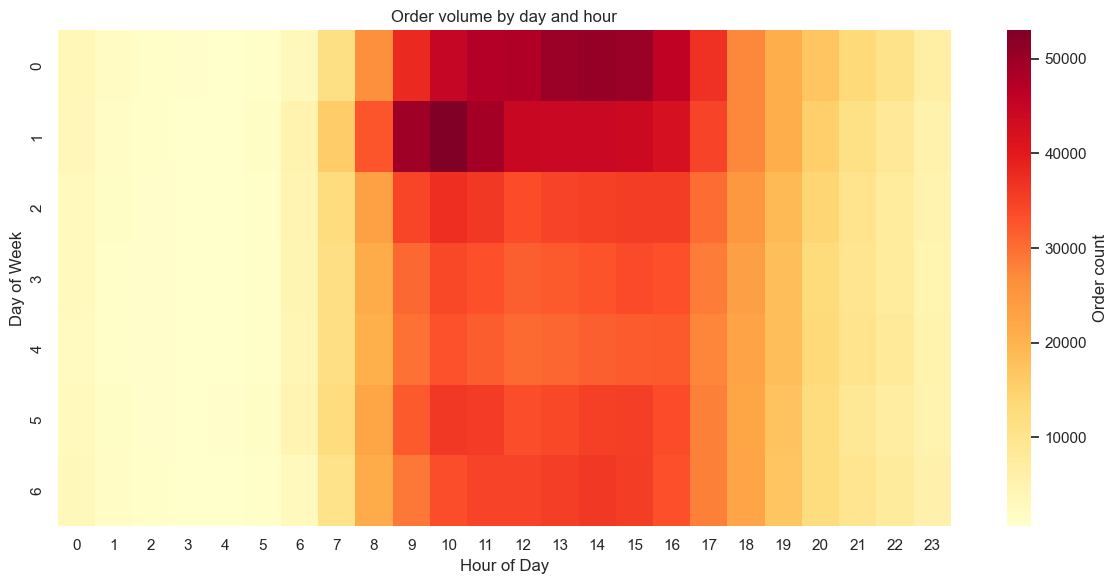

In [8]:
pivot = dow_hour.pivot(index='order_dow', columns='order_hour_of_day', values='n_orders').astype(float)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, cmap="YlOrRd", ax=ax, cbar_kws={"label": "Order count"})
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
ax.set_title('Order volume by day and hour')

plt.tight_layout()
plt.savefig("../outputs/figures/01_dow_hour_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
gap_dist = q("""
select days_since_prior_order, count(*) as n_orders
from `deneme-505002.instacart_clean.orders_prior`
where days_since_prior_order is not null
group by days_since_prior_order
order by days_since_prior_order
""")

gap_dist.head()

/Users/cemkulekci/anaconda3/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,days_since_prior_order,n_orders
0,0.0,64436
1,1.0,141011
2,2.0,187723
3,3.0,210665
4,4.0,214488


### 2. Sipariş Aralığı Dağılımı

Dağılımda iki tepe var ve ikisi neredeyse aynı yükseklikte: 7. günde 306.181
sipariş, 30. günde 306.137 sipariş. Aradaki fark 44 sipariş — ama bu iki
tepenin kaynağı tamamen farklı.

7'deki tepe gerçek: haftalık alışveriş ritmi. 7'nin katlarında da komşu
barlara göre yükselme var (14: 93.064, 21: 41.262, 28: 23.833), ancak bu
ikincil tepeler 7'ye kıyasla çok küçük.

Ağırlık 1-9 gün aralığında toplanmış, sonrasında kademeli olarak azalıyor.
0'da 64.436 sipariş var; bunlar aynı gün verilen ikinci siparişler.

**30'daki tepe ise yapay.** 29'da 16.976 sipariş varken 30'da 306.137 var —
18 katına çıkıyor.

**Sonucu:** Churn tanımı bu veriyle kurulamıyor. "Kaybedilmiş müşteri" ile
"geç dönen müşteri" ayırt edilemediği için müşteri kaybı analizi yapılamaz.
Ortalama sipariş aralığı olarak hesaplanan 11,1 gün de gerçek değil, bir
alt sınır.

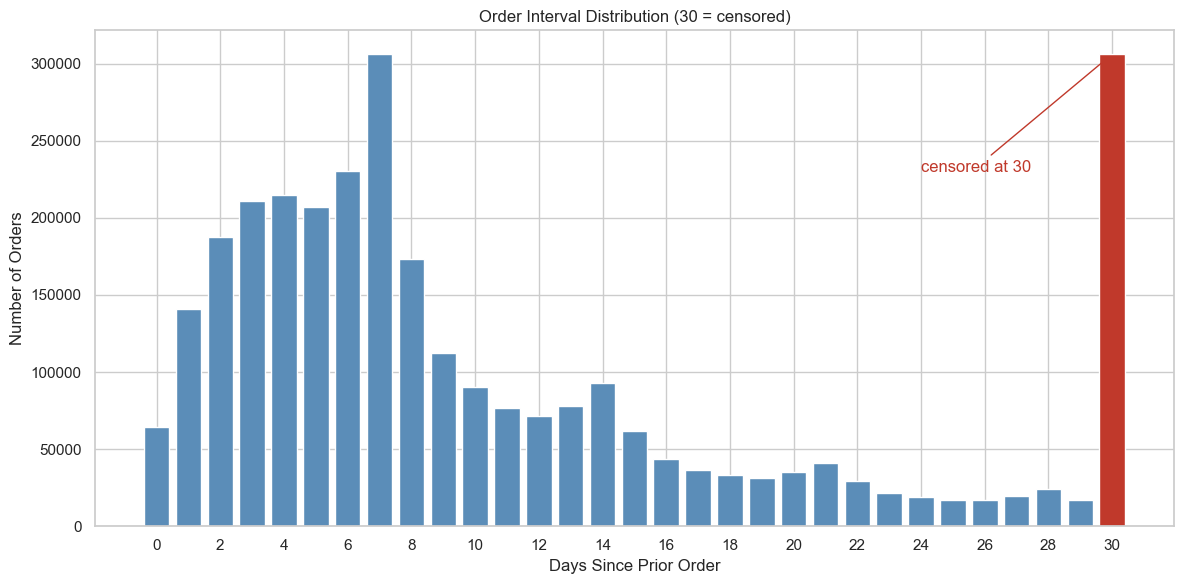

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ["#c0392b" if d == 30 else "#5b8db8" for d in gap_dist['days_since_prior_order']]
ax.bar(gap_dist['days_since_prior_order'], gap_dist['n_orders'], color=colors)

ax.set_xlabel('Days Since Prior Order')
ax.set_ylabel('Number of Orders')
ax.set_title('Order Interval Distribution (30 = censored)')
ax.set_xticks(range(0, 31, 2))

ax.annotate('censored at 30',
            xy=(30, gap_dist.loc[gap_dist['days_since_prior_order'] == 30, 'n_orders'].iloc[0]),
            xytext=(24, gap_dist['n_orders'].max() * 0.75),
            arrowprops=dict(arrowstyle='->', color="#c0392b"),
            color="#c0392b")

plt.tight_layout()
plt.savefig("../outputs/figures/02_order_interval.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
gap_dist[gap_dist['days_since_prior_order'].isin([0, 7, 14, 21, 28, 29, 30])]

,days_since_prior_order,n_orders
0,0.0,64436
7,7.0,306181
14,14.0,93064
21,21.0,41262
28,28.0,23833
29,29.0,16976
30,30.0,306137


In [12]:
order_seq = q("""
select
  order_number,
  count(*) / count(distinct order_id) as avg_basket_size,
  avg(reordered) as avg_reordered,
  count(distinct order_id) as n_orders
from `deneme-505002.instacart_clean.order_products_enriched`
group by order_number
order by order_number
""")

/Users/cemkulekci/anaconda3/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [13]:
order_seq.head()

,order_number,avg_basket_size,avg_reordered,n_orders
0,1,10.077484,0.000000,206209
1,2,9.933281,0.272361,206209
2,3,9.944915,0.386282,206209
3,4,9.989398,0.458345,182223
4,5,10.012796,0.507394,162633


### 3. Sipariş Sırasına Göre Tekrar Alım Oranı

Kırmızı eğri tekrar alım oranı. İlk siparişte 0'dan başlıyor, çünkü o noktada
tekrar edilecek geçmiş yok. Sonrasında hızla yükseliyor: 5. siparişte %51,
10. siparişte %64, 20. siparişte %74, 50. siparişte %82.

Artış hızı giderek düşüyor. İlk on siparişte 64 puan kazanılırken, sonraki
kırk siparişte sadece 18 puan ekleniyor. Eğri 30'dan sonra yataylaşıyor.

Mavi eğri sepet boyutu. Sağ eksen 10,0 ile 10,4 arasını gösterdiği için
dalgalı görünüyor, ama toplam fark 0,4 ürün. Sepet boyutu sabit sayılır.

**Özet:** Sipariş sayısı arttıkça kullanıcının aldığı ürün miktarı değişmiyor,
aldığı ürünlerin içeriği değişiyor. Sepet hep on ürün civarında; başta çoğu
yeni ürün, ilerledikçe çoğu tekrar.

**Dikkat — hayatta kalma yanlılığı:** Sağdaki noktalar giderek daha az
kullanıcıdan geliyor. 1. siparişte 206.209 kullanıcı varken 50. siparişte
10.910 kalıyor. Yani 50. siparişteki %82, 50 siparişe ulaşmış ağır
kullanıcılara ait; eğri bireysel değişimle kullanıcı kompozisyonu
değişimini birlikte taşıyor.

**Neden önemli:** Sepet boyutu sipariş sırasıyla değişmiyor — bu, kullanıcılar
arasında ayrım yaratmadığı anlamına gelmez, o ayrı bir soru. Tekrar alım oranı
ise güçlü bir sinyal.

Eşik optimizasyonu için referans on ürün DEĞİL: aday seti yalnızca prior'da
alınmış ürünlerden oluştuğu için modelin yakalayabileceği pozitif sayısı
kullanıcı başına ortalama 828.824 / 131.209 ≈ 6,3.

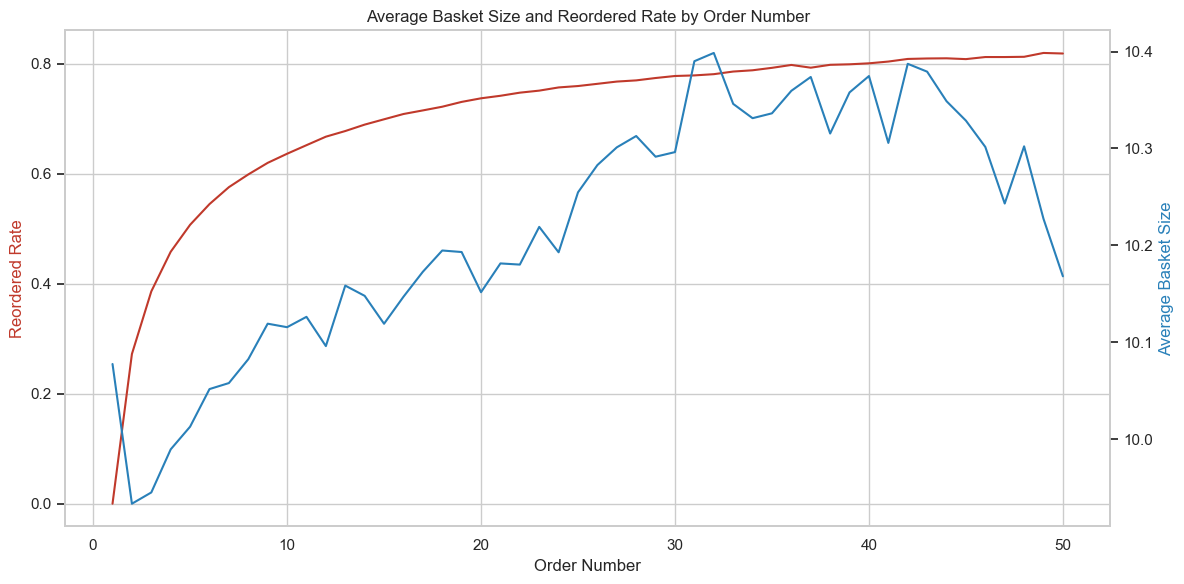

In [14]:
data = order_seq[order_seq['order_number'] <= 50]

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(data=data, x='order_number', y='avg_reordered', ax=ax1, color="#c0392b")
ax1.set_xlabel('Order Number')
ax1.set_ylabel('Reordered Rate', color="#c0392b")

ax2 = ax1.twinx()
sns.lineplot(data=data, x='order_number', y='avg_basket_size', ax=ax2, color="#2980b9")
ax2.set_ylabel('Average Basket Size', color="#2980b9")
ax2.grid(False)

plt.title('Average Basket Size and Reordered Rate by Order Number')

plt.tight_layout()
plt.savefig("../outputs/figures/03_order_sequence.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
order_seq[order_seq['order_number'].isin([1, 5, 10, 20, 30, 50])]

,order_number,avg_basket_size,avg_reordered,n_orders
0,1,10.077484,0.000000,206209
4,5,10.012796,0.507394,162633
9,10,10.115481,0.636637,101696
19,20,10.151584,0.737505,50731
29,30,10.296200,0.778087,29183
49,50,10.168011,0.818990,10910


In [16]:
cart_pos = q("""
select
  add_to_cart_order,
  avg(reordered) as avg_reordered,
  count(*) as n_rows
from `deneme-505002.instacart_clean.order_products_enriched`
group by add_to_cart_order
order by add_to_cart_order
""")

/Users/cemkulekci/anaconda3/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [17]:
cart_pos.shape

(145, 3)

### 4. Sepete Ekleme Sırasına Göre Tekrar Alım Oranı

Eğri sürekli düşüyor. Sepete ilk eklenen üründe tekrar oranı %67,8; 10. sırada
%55,1; 20. sırada %48,0; 40. sırada %40,9.

Düşüş ilk on sırada dik, sonra yavaşlıyor ve %40 civarında yataylaşmaya
başlıyor. İlk sıra ile 40. sıra arasında 27 puanlık fark var.

**Ne anlama geliyor:** Sepete ekleme sırası rastgele değil. Kullanıcı önce
düzenli aldığı ürünleri ekliyor, listenin sonuna doğru daha çok yeni ürün
giriyor.

**Karışma uyarısı:** Bu eğri havuzlanmış. 40. sıra yalnızca 40+ ürünlük
sepetlerde var, dolayısıyla konum etkisi sepet boyutuyla karışık. 27 puanın
ne kadarı konumdan, ne kadarı sepet boyutundan geliyor, bu grafik söylemiyor.

**Neden önemli:** Hedef siparişin `add_to_cart_order` değeri tahmin anında
BİLİNMEZ, o yüzden özellik olarak kullanılamaz. Modeldeki karşılığı prior'dan
hesaplanan ortalama konum: `up_avg_cart_position` ve `p_avg_cart_position`.

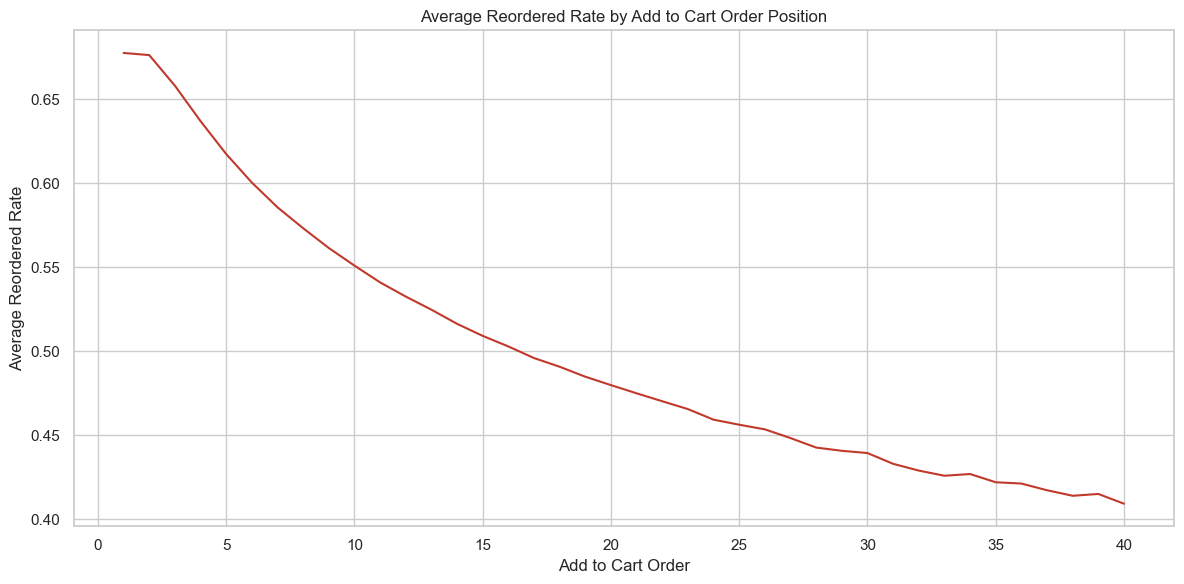

In [18]:
data = cart_pos[cart_pos['add_to_cart_order'] <=40]

plt.figure(figsize=(12, 6))

sns.lineplot(data=data, x='add_to_cart_order', y='avg_reordered', color="#c0392b")
plt.xlabel('Add to Cart Order')
plt.ylabel('Average Reordered Rate')
plt.title('Average Reordered Rate by Add to Cart Order Position')

plt.tight_layout()
plt.savefig("../outputs/figures/04_cart_position.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
cart_pos[cart_pos['add_to_cart_order'] > 60][['add_to_cart_order', 'n_rows']].head(20)

,add_to_cart_order,n_rows
60,61,813
61,62,713
62,63,634
63,64,567
64,65,510
65,66,457
66,67,408
67,68,364
68,69,325
69,70,301


In [20]:
cart_pos[cart_pos['add_to_cart_order'].isin([1, 10, 20, 40])]

,add_to_cart_order,avg_reordered,n_rows
0,1,0.677533,3214874
9,10,0.551018,1378293
19,20,0.479895,351506
39,40,0.409336,15960


In [21]:
dept = q("""
select
  department,
  count(*) as n_rows,
  count(distinct product_id) as n_products,
  avg(reordered) as reorder_rate
from `deneme-505002.instacart_clean.order_products_enriched`
group by department
""")

/Users/cemkulekci/anaconda3/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


### 5. Departman Bazında Normalize Tekrar Alım Oranı

Her departmanın tekrar alım oranından genel ortalama (%59) çıkarıldı. Sıfır
çizgisinin sağındakiler ortalamanın üstünde, solundakiler altında.

Altı departman pozitif: dairy eggs, beverages, produce, bakery, deli, pets.
Hepsi düzenli tüketilen, hızla biten ürünler. En yüksek dairy eggs, ortalamanın
yaklaşık 8 puan üstünde.

Negatif tarafta en uçta personal care var, ortalamanın 27 puan altında.
Onu pantry, international, missing ve household izliyor.

**Dikkat edilmesi gereken nokta:** Bu grafik sadakat farkını değil, büyük
ölçüde tüketim hızı farkını gösteriyor. Bu bir yorum değil, ölçülmüş bir
ilişki: ürün bazında tekrar alım oranı ile gerçek alım aralığı arasındaki
korelasyon r = -0,81 (n = 8.290 ürün). Düşük tekrar oranlı ürünlerde
ortalama alım aralığı 56 gün, yüksek olanlarda 21 gün. Negatif liftteki bir
departman "müşteri memnun değil" anlamına gelmiyor.

Not: burada normalizasyon genel ortalamadan sapma. SQL'deki ürün bazlı
analizde popülerlik dilimi (NTILE) normalizasyonu kullanıldı, ikisi farklı.

**Neden önemli:** Departman bazlı tekrar oranı modelde bir özellik olarak yer
alacak, ancak yorumu "kategori sadakati" değil "kategori yenilenme sıklığı"
olmalı. Ayrıca negatif liftteki departmanlar için tekrar alım hatırlatması
anlamsız — bu kategoriler çapraz satış alanı.

In [22]:
overall = dept["n_rows"].mul(dept["reorder_rate"]).sum() / dept["n_rows"].sum()
dept["lift"] = dept["reorder_rate"] - overall
dept = dept.sort_values("lift")

print(f"Overall Average: {overall:.3f}")

Overall Average: 0.590


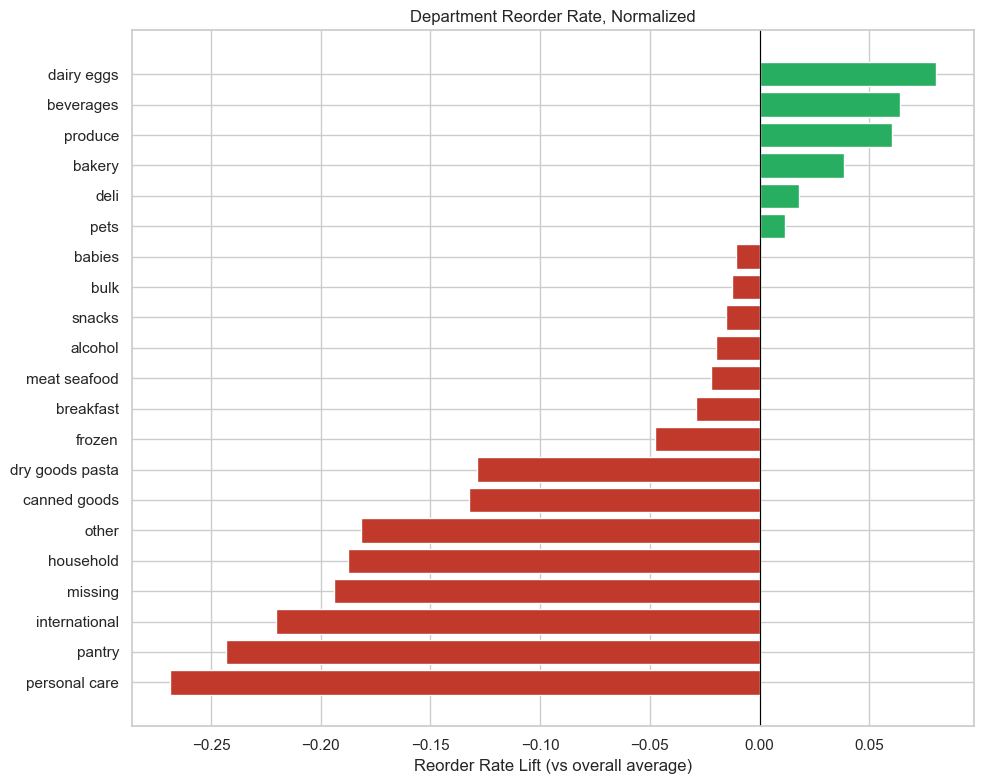

In [23]:
plt.figure(figsize=(10, 8))
colors = ["#c0392b" if x < 0 else "#27ae60" for x in dept["lift"]]
plt.barh(dept["department"], dept["lift"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Reorder Rate Lift (vs overall average)")
plt.title("Department Reorder Rate, Normalized")

plt.tight_layout()
plt.savefig("../outputs/figures/05_department_lift.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
lift_top = q("""
with product_stats as (
  select
    product_id,
    any_value(product_name) as product_name,
    any_value(aisle) as aisle,
    any_value(department) as department,
    count(*) as n_purchases,
    avg(reordered) as reorder_rate
  from `deneme-505002.instacart_clean.order_products_enriched`
  group by product_id
),
product_deciles as (
  select *, ntile(10) over (order by n_purchases, product_id) as popularity_decile
  from product_stats
  where n_purchases >= 500
),
decile_means as (
  select *, avg(reorder_rate) over (partition by popularity_decile) as decile_avg_reorder
  from product_deciles
),
ranked as (
  select
    product_name, department, n_purchases, reorder_rate,
    reorder_rate - decile_avg_reorder as reorder_lift,
    row_number() over (order by reorder_rate - decile_avg_reorder desc) as rn_high,
    row_number() over (order by reorder_rate - decile_avg_reorder asc) as rn_low
  from decile_means
  where popularity_decile >= 8
)
select
  case when rn_high <= 20 then 'high' else 'low' end as side,
  product_name, department, n_purchases, reorder_rate, reorder_lift
from ranked
where rn_high <= 20 or rn_low <= 20
order by reorder_lift desc
""")

print(lift_top['side'].value_counts())
lift_top.head()

/Users/cemkulekci/anaconda3/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


side
high    20
low     20
Name: count, dtype: int64


,side,product_name,department,n_purchases,reorder_rate,reorder_lift
0,high,Half And Half Ultra Pasteurized,dairy eggs,2921,0.861691,0.315586
1,high,Organic Homogenized Whole Milk,dairy eggs,3970,0.857683,0.281181
2,high,"Milk, Organic, Fat Free",dairy eggs,2615,0.826004,0.279899
3,high,Organic Nonfat Milk,dairy eggs,3063,0.820764,0.274659
4,high,Goat Milk,dairy eggs,5185,0.849952,0.273450


### 6. Normalize Tekrar Alım Oranı — En Yüksek ve En Düşük 20 Ürün

Ürünler satış sayısına göre 10 dilime bölündü, her ürünün kendi diliminin
ortalamasından sapması alındı. Böylece "çok satan ürün çok tekrar alınır"
etkisi elendi. Filtre: en az 500 satış, en popüler 3 dilim.

Pozitif tarafta süt ürünleri domine ediyor. En yüksek Half And Half Ultra
Pasteurized: 2.921 satış, %86,2 tekrar oranı, lift +0,316.

**Yöntem doğrulaması — muz testi:** Muz 472.565 satışla verinin en popüler
ürünü. Ham tekrar oranına bakılsaydı listeyi domine ederdi. Normalizasyon
sonrası hâlâ listede (+0,225), yani kendi diliminin 22 puan üstünde. Yöntem
popülerliği eliyor ama gerçek sinyali korumuş oluyor.

Negatif tarafta liste neredeyse tamamen pantry ve household: baharatlar,
sirkeler, folyo, vanilya özütü. En düşük Baking Powder: %9,0 tekrar oranı,
lift -0,487.

**Bu liste "denenip bırakılan ürünler" değil.** Negatif liftteki ürünler
uzun raf ömürlü ürünler. Bunu ölçtük: ürün bazında tekrar alım oranı ile
gerçek alım aralığı arasındaki korelasyon r = -0,81. En düşük tekrar oranlı
dilimde ortalama alım aralığı 56 gün, en yüksekte 21,4 gün. Bir kavanoz
defne yaprağı 83 günde bir, süt 14 günde bir alınıyor.

**Sonuç:** `reordered` kolonu "beğenmedi" ile "stoğu bitmedi"yi ayıramıyor.
Tekrar alım oranı sadakati değil, büyük ölçüde tüketim hızını ölçüyor.
Bu yüzden "kaygan ürün" (çok satılıp bırakılan) tanımı bu veriyle kurulamıyor
— kapsam beyanına girecek.

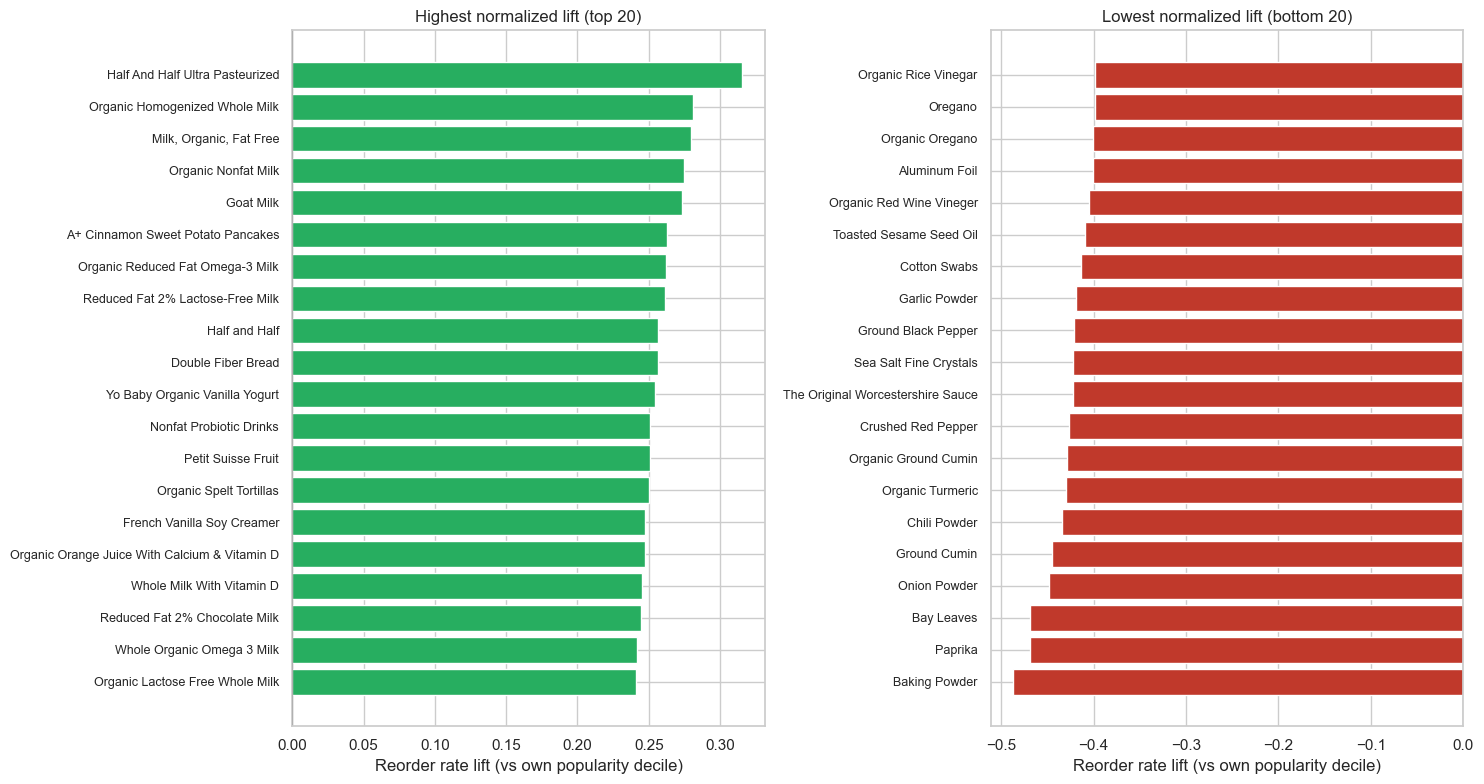

In [25]:
high = lift_top[lift_top['side'] == 'high'].sort_values('reorder_lift')
low = lift_top[lift_top['side'] == 'low'].sort_values('reorder_lift')

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

axes[0].barh(high['product_name'], high['reorder_lift'], color="#27ae60")
axes[0].set_title('Highest normalized lift (top 20)')
axes[0].set_xlabel('Reorder rate lift (vs own popularity decile)')

axes[1].barh(low['product_name'], low['reorder_lift'], color="#c0392b")
axes[1].set_title('Lowest normalized lift (bottom 20)')
axes[1].set_xlabel('Reorder rate lift (vs own popularity decile)')

for a in axes:
    a.axvline(0, color="black", linewidth=0.8)
    a.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/06_normalized_lift.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
repertoire = q("""
with all_orders as (
  select user_id, order_number
  from `deneme-505002.instacart_clean.orders_prior`
),
user_total as (
  select user_id, max(order_number) as total_orders
  from `deneme-505002.instacart_clean.orders_prior`
  group by user_id
),
first_visit as (
  select user_id, aisle, min(order_number) as first_order_number
  from `deneme-505002.instacart_clean.order_products_enriched`
  group by user_id, aisle
),
new_per_order as (
  select user_id, first_order_number as order_number, count(*) as new_aisles
  from first_visit
  group by user_id, first_order_number
),
filled as (
  select a.user_id, a.order_number, coalesce(n.new_aisles, 0) as new_aisles
  from all_orders a
  left join new_per_order n
    on a.user_id = n.user_id and a.order_number = n.order_number
),
cumulative as (
  select
    f.user_id,
    f.order_number,
    sum(f.new_aisles) over (
      partition by f.user_id order by f.order_number
      rows between unbounded preceding and current row
    ) as cum_unique_aisles,
    t.total_orders
  from filled f
  join user_total t on f.user_id = t.user_id
)
select
  order_number,
  count(distinct user_id) as n_users,
  avg(cum_unique_aisles) as avg_cum_aisles,
  avg(if(total_orders >= 20, cum_unique_aisles, null)) as cohort20_avg
from cumulative
group by order_number
order by order_number
""")

repertoire[repertoire['order_number'].isin([1, 5, 10, 20, 30, 50, 99])]

/Users/cemkulekci/anaconda3/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,order_number,n_users,avg_cum_aisles,cohort20_avg
0,1,206209,7.282155,7.659932
4,5,162633,19.099537,19.282096
9,10,101696,26.356189,26.189391
19,20,50731,34.313595,34.313595
29,30,29183,39.162458,39.162458
49,50,10910,45.188176,45.188176
98,99,1374,52.446870,52.446870


### 7. Kullanıcı Repertuar Eğrisi

Eğri kullanıcının o siparişe kadar ziyaret ettiği farklı koridor sayısını
gösteriyor. İlk siparişte ortalama 7,3 koridor, 5.'de 19,1, 10.'da 26,4,
20.'de 34,3, 50.'de 45,2.

Artış hızı sürekli düşüyor ama sıfırlanmıyor. İlk beş siparişte 12 koridor
ekleniyor, 50-99 arasındaki elli siparişte yalnızca 7 koridor. Yani keşif
yavaşlıyor, ancak bir doyum noktası yok — kullanıcı hiçbir noktada yeni
kategori denemeyi tamamen bırakmıyor.

**Hayatta kalma yanlılığı kontrolü:** Gri çizgi her sipariş numarasında kaç
kullanıcının hâlâ veride olduğunu gösteriyor — 1. siparişte 206.209, 50.'de
10.910. Sağdaki noktalar giderek daha küçük ve daha aktif bir gruptan geliyor.
Bunu ölçmek için yalnızca en az 20 siparişi olan kullanıcılarla ikinci bir
eğri çizildi (yeşil kesikli). İki eğri neredeyse üst üste: 10. siparişte fark
0,17 koridor. Yani eğrinin şekli kullanıcı kompozisyonundaki değişimden değil,
gerçek davranıştan geliyor.

**Neden önemli:** Repertuar doymadığı için "kullanıcı artık her şeyi denedi,
sadece tekrar alıyor" varsayımı kurulamaz. Ancak tekrar alım oranının sipariş
sayısıyla %0'dan %82'ye çıkması, yeni koridorların sepette giderek daha küçük
bir pay tuttuğunu gösteriyor.

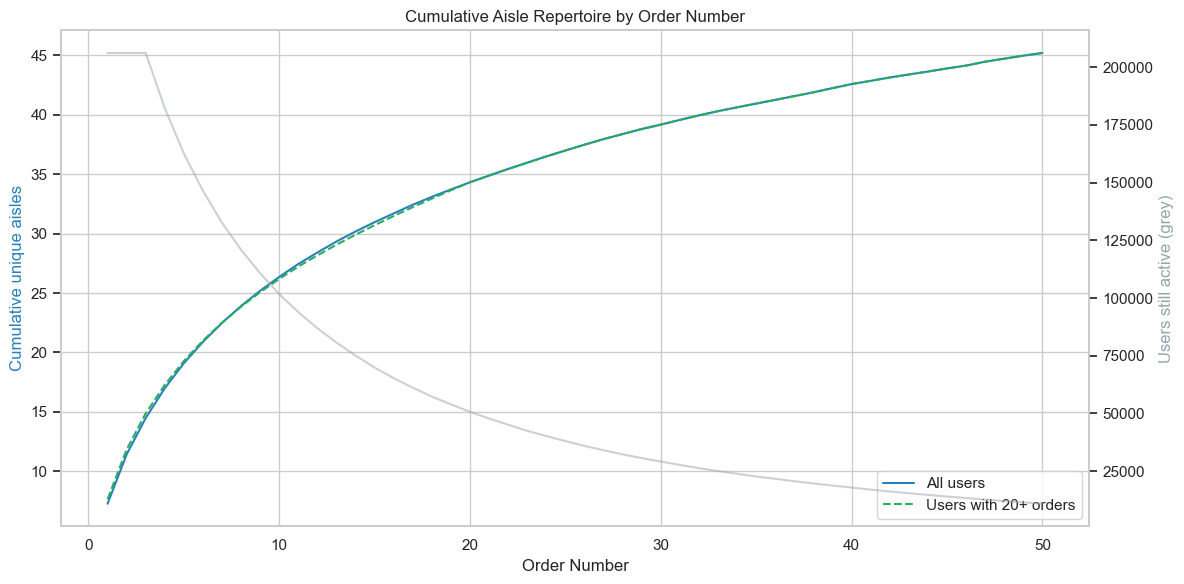

In [27]:
data = repertoire[repertoire['order_number'] <= 50]

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(data['order_number'], data['avg_cum_aisles'],
         color="#2980b9", label='All users')
ax1.plot(data['order_number'], data['cohort20_avg'],
         color="#27ae60", linestyle='--', label='Users with 20+ orders')
ax1.set_xlabel('Order Number')
ax1.set_ylabel('Cumulative unique aisles', color="#2980b9")
ax1.legend(loc='lower right')

ax2 = ax1.twinx()
ax2.plot(data['order_number'], data['n_users'], color="#95a5a6", alpha=0.5)
ax2.set_ylabel('Users still active (grey)', color="#95a5a6")
ax2.grid(False)

plt.title('Cumulative Aisle Repertoire by Order Number')

plt.tight_layout()
plt.savefig("../outputs/figures/07_repertoire.png", dpi=150, bbox_inches="tight")
plt.show()

In [28]:
basket_dist = q("""
with basket_counts as (
  select order_id, count(*) as basket_size
  from `deneme-505002.instacart_clean.order_products_enriched`
  group by order_id
)
select basket_size, count(*) as n_orders
from basket_counts
group by basket_size
order by basket_size
""")

total = basket_dist['n_orders'].sum()
weighted_mean = (basket_dist['basket_size'] * basket_dist['n_orders']).sum() / total
print(f"orders: {total:,}  mean: {weighted_mean:.2f}")

basket_dist[basket_dist['basket_size'].isin([1, 5, 6, 8, 10, 20, 50])]

/Users/cemkulekci/anaconda3/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


orders: 3,214,874  mean: 10.09


,basket_size,n_orders
0,1,156748
4,5,228330
5,6,227675
7,8,203374
9,10,165550
19,20,48096
49,50,491


### 8. Sepet Boyutu Dağılımı

Dağılım sağa çarpık. Tepe 5-6 ürün civarında, medyan 8, ortalama 10,1.
Ortalamanın medyandan yüksek olması uzun kuyruktan geliyor: 50 ürünün
üstünde sepetler var ama sayıları çok az.

Üç referans çizgisi arasındaki fark modelleme açısından önemli:

- **Ortalama 10,1** — kullanıcının gerçekte aldığı ürün sayısı
- **Ulaşılabilir 6,3** — modelin yakalayabileceği pozitif sayısı
  (828.824 / 131.209)

Aradaki ~3,8 ürünlük boşluk aday setinin sınırından geliyor. Train
siparişindeki ürünlerin %40,1'i kullanıcının prior'da hiç almadığı ürünler
ve bunlar aday listesinde olmadığı için model onları asla yakalayamıyor.

**Neden önemli:** Eşik optimizasyonunda kullanıcı başına kaç ürün önerileceği
kararının referansı 10 değil 6,3. Daha fazla ürün önermek precision'ı düşürür,
çünkü yakalanabilecek pozitif zaten ortalama 6,3 tane.

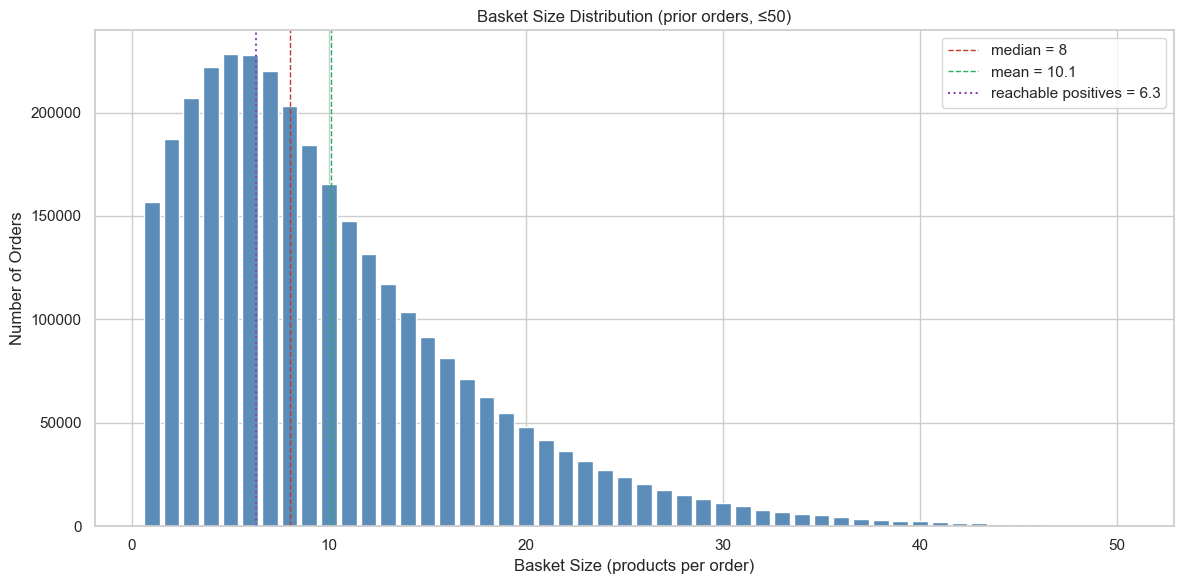

In [29]:
data = basket_dist[basket_dist['basket_size'] <= 50]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(data['basket_size'], data['n_orders'], color="#5b8db8")

ax.axvline(8, color="#c0392b", linestyle='--', linewidth=1, label='median = 8')
ax.axvline(weighted_mean, color="#27ae60", linestyle='--', linewidth=1,
           label=f'mean = {weighted_mean:.1f}')
ax.axvline(6.3, color="#8e44ad", linestyle=':', linewidth=1.5,
           label='reachable positives = 6.3')

ax.set_xlabel('Basket Size (products per order)')
ax.set_ylabel('Number of Orders')
ax.set_title('Basket Size Distribution (prior orders, ≤50)')
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/08_basket_size.png", dpi=150, bbox_inches="tight")
plt.show()

In [30]:
df = load_training_set("training_set.parquet")
print(memory_report(df))

8,474,661 satir x 53 kolon — 1.42 GB


In [31]:
df.head()

,user_id,product_id,target,u_n_orders,u_total_items,u_n_products,u_n_aisles,u_n_departments,u_avg_basket,u_sd_basket,u_avg_gap,u_sd_gap,u_reorder_rate,u_hour_sin,u_hour_cos,u_top_dow,u_days_since_last_order,p_n_purchases,p_n_users,p_reorder_rate,p_second_purchase_rate,p_avg_times_per_user,p_avg_cart_position,p_avg_repeat_gap,p_popularity_decile,p_reorder_lift,a_n_purchases,a_n_users,a_n_products,a_reorder_rate,a_second_purchase_rate,a_avg_cart_position,a_avg_repeat_gap,a_purchases_per_user,d_n_purchases,d_n_users,d_n_products,d_n_aisles,d_reorder_rate,d_second_purchase_rate,d_avg_cart_position,d_avg_repeat_gap,d_purchases_per_user,up_n_purchases,up_first_order,up_last_order,up_orders_since_last,up_days_since_last,up_order_rate,up_last5_purchases,up_avg_cart_position,up_avg_repeat_gap,up_share_of_orders
0,56394,25890,0,8,133,101,43,15,16.625000,10.432607,20.428572,11.588171,0.240602,0.212247,-0.459129,6,30.0,50281,16995,0.662000,0.538688,2.958576,7.513912,28.757586,10,0.107411,118437,38155,99,0.599230,0.547871,8.001748,29.407242,3.104102,708931,113891,907,7,0.567674,0.727608,8.528225,24.229822,6.224645,2,1,2,6,143.0,0.250000,0,5.00,30.000000,0.250000
1,8240,3174,0,37,267,80,34,13,7.216216,3.757475,9.527778,6.049728,0.700375,-0.767902,0.089506,4,4.0,51,37,0.274510,0.243243,1.378378,9.843137,29.142857,5,-0.096154,129474,27077,159,0.607775,0.599919,8.946708,26.482355,4.781697,1051249,133865,1322,5,0.607719,0.754312,8.693814,22.031942,7.853054,3,1,6,31,300.0,0.081081,0,7.00,23.500000,0.081081
2,27207,7916,0,15,343,131,46,16,22.866667,7.443758,18.285715,8.552360,0.618076,0.159772,-0.319858,3,30.0,6639,1808,0.727670,0.551438,3.672013,6.630969,21.494722,10,0.173082,99032,25608,317,0.619759,0.543072,8.162735,25.551628,3.867229,1051249,133865,1322,5,0.607719,0.754312,8.693814,22.031942,7.853054,4,3,6,9,203.0,0.307692,0,12.75,18.333334,0.266667
3,101018,28373,0,30,292,134,50,13,9.733334,6.169633,11.689655,8.932698,0.541096,0.256060,-0.762444,1,14.0,7335,2220,0.697342,0.566216,3.304054,7.198364,29.741739,10,0.142753,99032,25608,317,0.619759,0.543072,8.162735,25.551628,3.867229,1051249,133865,1322,5,0.607719,0.754312,8.693814,22.031942,7.853054,2,23,25,5,61.0,0.250000,0,13.00,14.000000,0.066667
4,92115,35956,0,17,317,97,35,16,18.647058,6.509044,19.812500,5.075677,0.694006,-0.619808,-0.241894,5,30.0,917,292,0.681570,0.513699,3.140411,8.241003,25.204800,9,0.192411,63421,7908,499,0.620883,0.644031,7.512244,23.778418,8.019854,97724,14986,972,2,0.601285,0.594622,7.718544,24.786730,6.521019,2,6,12,5,145.0,0.166667,0,9.50,105.000000,0.117647


In [32]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8474661 entries, 0 to 8474660
Data columns (total 53 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   user_id                  int32  
 1   product_id               int32  
 2   target                   int8   
 3   u_n_orders               int8   
 4   u_total_items            int16  
 5   u_n_products             int16  
 6   u_n_aisles               int8   
 7   u_n_departments          int8   
 8   u_avg_basket             float32
 9   u_sd_basket              float32
 10  u_avg_gap                float32
 11  u_sd_gap                 float32
 12  u_reorder_rate           float32
 13  u_hour_sin               float32
 14  u_hour_cos               float32
 15  u_top_dow                int8   
 16  u_days_since_last_order  float32
 17  p_n_purchases            int32  
 18  p_n_users                int32  
 19  p_reorder_rate           float32
 20  p_second_purchase_rate   float32
 21  p_avg_ti

In [33]:
df.shape

(8474661, 53)

In [34]:
train, valid, test = user_level_split(df, val_fraction=0.15, test_fraction=0.15, seed=42)

import pprint
pprint.pprint(verify_split(train, valid, test))

{'overlap_train_test': 0,
 'overlap_train_val': 0,
 'overlap_val_test': 0,
 'test_positive_rate': 0.09847314916951695,
 'test_rows': 1260110,
 'test_users': 19681,
 'train_positive_rate': 0.09754718821143817,
 'train_rows': 5947460,
 'train_users': 91847,
 'val_positive_rate': 0.09831890527199703,
 'val_rows': 1267091,
 'val_users': 19681}


# Baseline 0 ve 1

***Hiç bir şey önerme. Tüm tahminler 0. Alt sınır***


***Baseline 1 kullancının prior'da aldığı her ürünü öner. Tüm tahminler 1.Recall tavanda, precision dipte.***

In [35]:
results = []

# Baseline0 - hiçbir şey önerme
valid_b0 = valid[['user_id', 'target']].copy()
valid_b0['prediction'] = 0
f1_b0 = user_f1(valid_b0)
results.append({'baseline': '0: predict nothing', 'user_f1': f1_b0})
print(f"Baseline 0: {f1_b0:.4f}")

# Baseline1 - aday setinin tamamini oner
valid_b1 = valid[['user_id', 'target']].copy()
valid_b1['prediction'] = 1
f1_b1 = user_f1(valid_b1)
results.append({'baseline': '1: predict everything', 'user_f1': f1_b1})
print(f"Baseline 1: {f1_b1:.4f}")

Baseline 0: 0.0000
Baseline 1: 0.2153


## Baseline 2

***Son siparişini aynen tekrarla***

In [36]:
valid_b2 = valid[['user_id', 'target', 'up_orders_since_last']].copy()
valid_b2['prediction'] = (valid_b2['up_orders_since_last'] == 0).astype(int)

f1_b2 = user_f1(valid_b2)
results.append({'baseline': '2: repeat last order', 'user_f1': f1_b2})
print(f"Baseline 2: {f1_b2:.4f}")
print(f"avg items recommended per user: {valid_b2['prediction'].sum() / valid_b2['user_id'].nunique():.2f}")

Baseline 2: 0.3123
avg items recommended per user: 10.33


## Baseline 3

***En sık aldıgı N ürün***

In [37]:
# Baseline 3 - en sik alinan N urunu oner
b3 = valid[['user_id','target','up_n_purchases','product_id']].copy()
b3['rank'] = b3.groupby('user_id')['up_n_purchases'].rank(method='first', ascending=False)

for n in [5, 10, 15 ,20]:
    b3['prediction'] = (b3['rank'] <= n).astype(int)
    f1 = user_f1(b3)
    results.append({'baseline': f'3: top {n} most purchased', 'user_f1': f1})
    print(f"Baseline 3 (N={n}): {f1:.4f}")

Baseline 3 (N=5): 0.2932
Baseline 3 (N=10): 0.3068
Baseline 3 (N=15): 0.2990
Baseline 3 (N=20): 0.2880


## Baseline 4 

***Alım oranı belli bir eşiğin üstündeki ürünleri öner***

In [38]:
# Baseline 4 - alim orani esigin ustundeki urunleri oner
b4 = valid[['user_id', 'target', 'up_order_rate']].copy()

best = None
for th in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]:
    b4['prediction'] = (b4['up_order_rate'] >= th).astype(int)
    f1 = user_f1(b4)
    avg_rec = b4['prediction'].sum() / b4['user_id'].nunique()
    print(f"threshold {th:.2f}: F1 = {f1:.4f}  (avg {avg_rec:.1f} items)")
    if best is None or f1 > best[1]:
        best = (th, f1)

results.append({'baseline': f'4: order rate >= {best[0]:.2f}', 'user_f1': best[1]})
print(f"\nbest threshold: {best[0]:.2f} -> F1 = {best[1]:.4f}")

threshold 0.10: F1 = 0.2389  (avg 46.7 items)
threshold 0.15: F1 = 0.2602  (avg 37.7 items)
threshold 0.20: F1 = 0.2720  (avg 33.2 items)
threshold 0.25: F1 = 0.2851  (avg 28.5 items)
threshold 0.30: F1 = 0.3008  (avg 23.2 items)
threshold 0.35: F1 = 0.3178  (avg 17.7 items)
threshold 0.40: F1 = 0.3138  (avg 16.9 items)
threshold 0.50: F1 = 0.3029  (avg 14.8 items)

best threshold: 0.35 -> F1 = 0.3178


In [39]:
# Baseline karsilastirma tablosu
baseline_table = pd.DataFrame(results).sort_values('user_f1', ascending=False).reset_index(drop=True)
baseline_table['pct_of_ceiling'] = baseline_table['user_f1'] / 0.6986

baseline_table

,baseline,user_f1,pct_of_ceiling
0,4: order rate >= 0.35,0.317808,0.454921
1,2: repeat last order,0.312316,0.447060
2,3: top 10 most purchased,0.306761,0.439108
3,3: top 15 most purchased,0.298997,0.427994
4,3: top 5 most purchased,0.293211,0.419712
5,3: top 20 most purchased,0.288033,0.412300
6,1: predict everything,0.215327,0.308227
7,0: predict nothing,0.000000,0.000000


In [40]:
print(lgb.__version__, sklearn.__version__)

4.7.0 1.5.2


In [41]:
# user_id ve product_id özellik değil, kimlik
DROP = ['user_id', 'product_id', 'target', 'up_last_order']
FEATURES = [c for c in train.columns if c not in DROP]
print(f"{len(FEATURES)} features")

# lr yorumlama amacki: 500k satirlik rastgele ornek yeterli
lr_sample = train.sample(n=500_000, random_state=42)

X_lr = lr_sample[FEATURES].astype('float32')
y_lr = lr_sample['target'].to_numpy()

# LR NaN kabul etmez; medyen ile dolduruyoruz
medians = X_lr.median()
X_lr = X_lr.fillna(medians)

scaler = StandardScaler()
X_lr_scaled = scaler.fit_transform(X_lr)

lr = LogisticRegression(max_iter=1000, n_jobs=-1)
lr.fit(X_lr_scaled, y_lr)

coefs = pd.DataFrame({
    'feature': FEATURES,
    'coef': lr.coef_[0]
}).sort_values('coef', key=abs, ascending=False).reset_index(drop=True)

del lr_sample, X_lr, X_lr_scaled
gc.collect()

coefs.head(15)

49 features


,feature,coef
0,up_days_since_last,-0.498820
1,up_orders_since_last,-0.389473
2,u_reorder_rate,0.322351
3,up_last5_purchases,0.310049
4,p_second_purchase_rate,0.233311
5,up_share_of_orders,0.209366
6,up_order_rate,0.200220
7,p_avg_times_per_user,-0.179434
8,up_first_order,-0.170639
9,p_reorder_lift,0.123381


In [42]:
cols = ['p_reorder_rate', 'p_second_purchase_rate', 'p_avg_times_per_user', 'p_n_purchases']
train[cols].corr().round(3)

,p_reorder_rate,p_second_purchase_rate,p_avg_times_per_user,p_n_purchases
p_reorder_rate,1.000,0.964,0.887,0.420
p_second_purchase_rate,0.964,1.000,0.904,0.530
p_avg_times_per_user,0.887,0.904,1.000,0.623
p_n_purchases,0.420,0.530,0.623,1.000


In [43]:
cols = ['p_reorder_rate', 'p_second_purchase_rate', 'p_avg_times_per_user', 'p_n_purchases']
train[cols].corr().round(3)

,p_reorder_rate,p_second_purchase_rate,p_avg_times_per_user,p_n_purchases
p_reorder_rate,1.000,0.964,0.887,0.420
p_second_purchase_rate,0.964,1.000,0.904,0.530
p_avg_times_per_user,0.887,0.904,1.000,0.623
p_n_purchases,0.420,0.530,0.623,1.000


### Lojistik Regresyon — Katsayı İşaretleri

Amaç yüksek skor değil, işaretlerin mantıklı olup olmadığını kontrol etmek.

**Beklendiği gibi çıkanlar:**

En güçlü iki katsayı zamanlama: `up_days_since_last` (-0,499) ve
`up_orders_since_last` (-0,389). İkisi de negatif — uzun süredir almadığı
bir ürünü tekrar alma ihtimali düşüyor. Bu, Baseline 2'nin (son siparişi
tekrarla, F1 = 0,3123) Baseline 3'ü (en sık alınan N ürün, F1 = 0,3068)
geçmesiyle tutarlı: zamanlama hacimden güçlü bir sinyal.

Diğer işaretler de beklenen yönde: kullanıcının genel tekrar oranı (+0,322),
son 5 siparişteki alım (+0,310), ürünün genel tekrar oranı (+0,110) pozitif;
ürünü geç keşfetmiş olmak (-0,171) ve sepete geç eklemek (-0,078) negatif.
Sepet pozisyonunun negatif olması Grafik 4'teki düşen eğriyle uyumlu.

**Tek beklenmedik işaret: `p_avg_times_per_user` = -0,179**

Kolon "bu ürünü alan kullanıcılar ortalama kaç kez almış" anlamına geliyor,
pozitif olması beklenirdi. Sızıntı değil — sızıntı skoru şişirir, işaret
ters çevirmez.

Sebep çoklu doğrusal bağlantı. Üç ürün kolonu neredeyse aynı şeyi ölçüyor:

    p_reorder_rate ↔ p_second_purchase_rate : 0,964
    p_second_purchase_rate ↔ p_avg_times_per_user : 0,904
    p_reorder_rate ↔ p_avg_times_per_user : 0,887

Bu seviyede korelasyonda LR toplam etkiyi kolonlar arasında keyfi
bölüştürür ve birine negatif katsayı verebilir. Katsayılar tek tek
yorumlanamaz.

**Sonuç:** İşaret kontrolü geçti. LightGBM'de bu sorun yok — ağaç modeli
korelasyonlu özellikleri katsayı çatışması olmadan kullanabiliyor, bu yüzden
kolonları çıkarmıyoruz.

In [44]:
X_val_lr = valid[FEATURES].astype('float32').fillna(medians)
X_val_lr = scaler.transform(X_val_lr)

val_lr = valid[['user_id', 'target']].copy()
val_lr['proba'] = lr.predict_proba(X_val_lr)[:, 1]

del X_val_lr
gc.collect()

best_lr = None
for th in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]:
    val_lr['prediction'] = (val_lr['proba'] >= th).astype(int)
    f1 = user_f1(val_lr)
    print(f"threshold {th:.2f}: F1 = {f1:.4f}")
    if best_lr is None or f1 > best_lr[1]:
        best_lr = (th, f1)

print(f"\nlogistic regression best: threshold {best_lr[0]:.2f} -> F1 = {best_lr[1]:.4f}")

threshold 0.10: F1 = 0.3336
threshold 0.15: F1 = 0.3594
threshold 0.20: F1 = 0.3521
threshold 0.25: F1 = 0.3301
threshold 0.30: F1 = 0.3023
threshold 0.35: F1 = 0.2731
threshold 0.40: F1 = 0.2445

logistic regression best: threshold 0.15 -> F1 = 0.3594


In [45]:
# LR sonucunu karsilastirma tablosuna ekle
results.append({'baseline': f'LR (threshold {best_lr[0]:.2f})', 'user_f1': best_lr[1]})

comparison = pd.DataFrame(results).sort_values('user_f1', ascending=False).reset_index(drop=True)
comparison['pct_of_ceiling'] = comparison['user_f1'] / 0.6986

comparison

,baseline,user_f1,pct_of_ceiling
0,LR (threshold 0.15),0.359402,0.514460
1,4: order rate >= 0.35,0.317808,0.454921
2,2: repeat last order,0.312316,0.447060
3,3: top 10 most purchased,0.306761,0.439108
4,3: top 15 most purchased,0.298997,0.427994
5,3: top 5 most purchased,0.293211,0.419712
6,3: top 20 most purchased,0.288033,0.412300
7,1: predict everything,0.215327,0.308227
8,0: predict nothing,0.000000,0.000000


In [46]:
LGB_FEATURES = [c for c in train.columns if c not in ['user_id', 'product_id', 'target']]
print(f"{len(LGB_FEATURES)} features")

dtrain = lgb.Dataset(
    train[LGB_FEATURES], label=train['target'].to_numpy(),
    feature_name=LGB_FEATURES, free_raw_data=True
)
dvalid = lgb.Dataset(
    valid[LGB_FEATURES], label=valid['target'].to_numpy(),
    reference=dtrain, free_raw_data=True
)

params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'min_data_in_leaf': 200,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'verbose': -1,
    'num_threads': 4,
    'seed': 42,
    'deterministic': True,
    'force_row_wise': True,
}

t0 = time.time()
model = lgb.train(
    params, dtrain,
    num_boost_round=1000,
    valid_sets=[dvalid], valid_names=['valid'],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=50)],
)
elapsed = time.time() - t0

print(f"best iteration: {model.best_iteration}")
print(f"best logloss: {model.best_score['valid']['binary_logloss']:.5f}")
print(f"training time: {elapsed/60:.1f} min")
gc.collect()

50 features
Training until validation scores don't improve for 50 rounds
[50]	valid's binary_logloss: 0.24697
[100]	valid's binary_logloss: 0.244559
[150]	valid's binary_logloss: 0.244106
[200]	valid's binary_logloss: 0.2439
[250]	valid's binary_logloss: 0.243776
[300]	valid's binary_logloss: 0.243704
[350]	valid's binary_logloss: 0.24366
[400]	valid's binary_logloss: 0.243647
[450]	valid's binary_logloss: 0.243606
[500]	valid's binary_logloss: 0.243594
[550]	valid's binary_logloss: 0.243575
[600]	valid's binary_logloss: 0.243584
Early stopping, best iteration is:
[553]	valid's binary_logloss: 0.243571
best iteration: 553
best logloss: 0.24357
training time: 1.9 min


498

In [47]:
val_lgb = valid[['user_id', 'target']].copy()
val_lgb['proba'] = model.predict(valid[LGB_FEATURES], num_iteration=model.best_iteration)

best_lgb = None
for th in [0.10, 0.15, 0.18, 0.20, 0.22, 0.25, 0.30, 0.35]:
    val_lgb['prediction'] = (val_lgb['proba'] >= th).astype(int)
    f1 = user_f1(val_lgb)
    avg_rec = val_lgb['prediction'].sum() / val_lgb['user_id'].nunique()
    print(f"threshold {th:.2f}: F1 = {f1:.4f}  (avg {avg_rec:.1f} items)")
    if best_lgb is None or f1 > best_lgb[1]:
        best_lgb = (th, f1)

print(f"\nLightGBM best: threshold {best_lgb[0]:.2f} -> F1 = {best_lgb[1]:.4f}")

threshold 0.10: F1 = 0.3470  (avg 18.1 items)
threshold 0.15: F1 = 0.3689  (avg 12.3 items)
threshold 0.18: F1 = 0.3712  (avg 10.1 items)
threshold 0.20: F1 = 0.3693  (avg 8.9 items)
threshold 0.22: F1 = 0.3643  (avg 8.0 items)
threshold 0.25: F1 = 0.3551  (avg 6.7 items)
threshold 0.30: F1 = 0.3331  (avg 5.2 items)
threshold 0.35: F1 = 0.3058  (avg 4.1 items)

LightGBM best: threshold 0.18 -> F1 = 0.3712


In [48]:
results.append({'baseline': f'LightGBM (threshold {best_lgb[0]:.2f})', 'user_f1': best_lgb[1]})

comparison = pd.DataFrame(results).sort_values('user_f1', ascending=False).reset_index(drop=True)
comparison['pct_of_ceiling'] = comparison['user_f1'] / 0.6986

import os
os.makedirs("../outputs/models", exist_ok=True)
model.save_model("../outputs/models/lgbm_model.txt", num_iteration=model.best_iteration)
print("model saved")

comparison

model saved


,baseline,user_f1,pct_of_ceiling
0,LightGBM (threshold 0.18),0.371241,0.531408
1,LR (threshold 0.15),0.359402,0.514460
2,4: order rate >= 0.35,0.317808,0.454921
3,2: repeat last order,0.312316,0.447060
4,3: top 10 most purchased,0.306761,0.439108
5,3: top 15 most purchased,0.298997,0.427994
6,3: top 5 most purchased,0.293211,0.419712
7,3: top 20 most purchased,0.288033,0.412300
8,1: predict everything,0.215327,0.308227
9,0: predict nothing,0.000000,0.000000


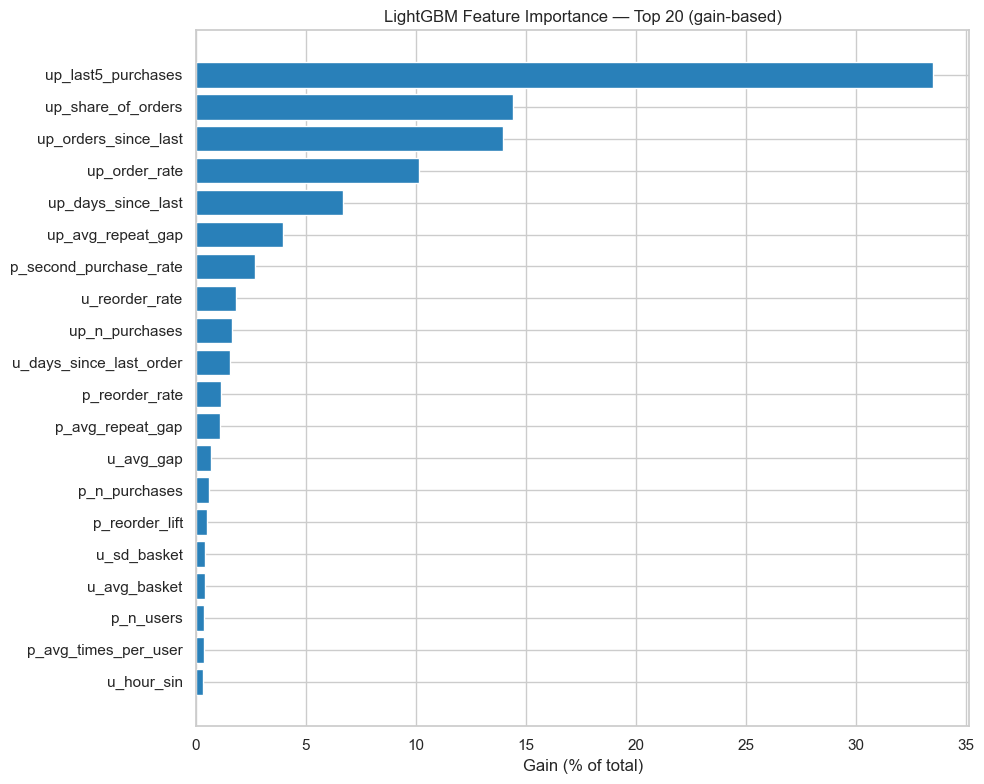

,feature,gain_pct,split
0,up_last5_purchases,33.502524,302
1,up_share_of_orders,14.438523,956
2,up_orders_since_last,13.964146,685
3,up_order_rate,10.150835,725
4,up_days_since_last,6.689219,2162
5,up_avg_repeat_gap,3.959640,1235
6,p_second_purchase_rate,2.693291,877
7,u_reorder_rate,1.834031,1993
8,up_n_purchases,1.644571,373
9,u_days_since_last_order,1.565893,1461


In [49]:
imp = pd.DataFrame({
    'feature': model.feature_name(),
    'gain': model.feature_importance(importance_type='gain'),
    'split': model.feature_importance(importance_type='split'),
}).sort_values('gain', ascending=False).reset_index(drop=True)

imp['gain_pct'] = imp['gain'] / imp['gain'].sum() * 100

top20 = imp.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top20['feature'][::-1], top20['gain_pct'][::-1], color="#2980b9")
ax.set_xlabel('Gain (% of total)')
ax.set_title('LightGBM Feature Importance — Top 20 (gain-based)')
plt.tight_layout()
plt.savefig("../outputs/figures/09_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

top20[['feature', 'gain_pct', 'split']]

### 9. Özellik Önemi — LightGBM (gain bazlı)

Gain, bir özellik bölünmede kullanıldığında modele kattığı iyileşmeyi ölçüyor.
Split ise kaç kez kullanıldığını sayıyor. İkisi birlikte okunmalı.

**Planın beklentisi karşılandı.** Adım 1.6'da "son alımdan bu yana kaç sipariş
geçmiş ve son 5 siparişte kaç kez almış en güçlü iki sinyal olacak; üstte
görmezsen bir şey yanlış demektir" yazılmıştı. İlk beş sıranın tamamı
kullanıcı-ürün özellikleri ve toplam gain'in %78,7'sini alıyorlar:

    up_last5_purchases      %33,5   (302 split)
    up_share_of_orders      %14,4   (956 split)
    up_orders_since_last    %14,0   (685 split)
    up_order_rate           %10,2   (725 split)
    up_days_since_last       %6,7  (2.162 split)

**Gain ile split neden ayrı okunmalı:**

`up_last5_purchases` gain'in üçte birini alıyor ama yalnızca 302 bölünmede
kullanılmış. Az kullanılıp çok katkı veriyor — ağacın üst dallarında oturuyor,
model önce bu soruyu soruyor ve veriyi ona göre ikiye ayırıyor.

`up_days_since_last` tam tersi: 2.162 bölünme ama %6,7 gain. Sık kullanılıyor,
her seferinde küçük düzeltme yapıyor. İnce ayar özelliği.

**Sızıntı kontrolü:** Beklenmedik bir özellik üstte değil. Sıralama Kontrol
3'teki korelasyon taramasıyla tutarlı (orada da up_last5_purchases r = 0,386
ile birinciydi). Hedefin kendisini içeren bir özellik olsaydı gain'i ezici
olurdu ve logloss çok daha düşük çıkardı.

**SQL düzeltmelerinin karşılığı:** Düzeltilmiş `up_avg_repeat_gap` 6. sırada
(%3,96), `p_avg_repeat_gap` 12. sırada (%1,11). Eski hatalı versiyonlar
ürünün alım aralığını değil kullanıcının sipariş aralığını ölçüyordu.
`u_hour_sin` 20. sırada — döngüsel saat düzeltmesi modele giriyor ama katkısı
küçük.

**Kategori özellikleri zayıf.** Koridor ve departman kolonlarının hiçbiri ilk
20'de yok. Kullanıcı-ürün düzeyinde yeterli veri olduğu için model kategori
ortalamasına ihtiyaç duymuyor.

In [50]:
TOP_N = 10
perm_features = imp['feature'].head(TOP_N).tolist()

X_val = valid[LGB_FEATURES].copy()
base_pred = valid[['user_id', 'target']].copy()
base_pred['proba'] = model.predict(X_val, num_iteration=model.best_iteration)
base_pred['prediction'] = (base_pred['proba'] >= best_lgb[0]).astype(int)
base_f1 = user_f1(base_pred)
print(f"baseline F1 (no shuffle): {base_f1:.4f}\n")

rng = np.random.default_rng(42)
perm_rows = []

for feat in perm_features:
    original = X_val[feat].to_numpy(copy=True)
    X_val[feat] = rng.permutation(original)

    tmp = valid[['user_id', 'target']].copy()
    tmp['proba'] = model.predict(X_val, num_iteration=model.best_iteration)
    tmp['prediction'] = (tmp['proba'] >= best_lgb[0]).astype(int)
    f1_shuffled = user_f1(tmp)

    X_val[feat] = original

    drop = base_f1 - f1_shuffled
    perm_rows.append({'feature': feat, 'f1_shuffled': f1_shuffled, 'f1_drop': drop})
    print(f"{feat:28s} F1 = {f1_shuffled:.4f}  drop = {drop:.4f}")

    del tmp
    gc.collect()

perm = pd.DataFrame(perm_rows).sort_values('f1_drop', ascending=False).reset_index(drop=True)

del X_val
gc.collect()

perm

baseline F1 (no shuffle): 0.3712

up_last5_purchases           F1 = 0.3630  drop = 0.0082
up_share_of_orders           F1 = 0.3491  drop = 0.0221
up_orders_since_last         F1 = 0.3521  drop = 0.0191
up_order_rate                F1 = 0.3652  drop = 0.0061
up_days_since_last           F1 = 0.3232  drop = 0.0481
up_avg_repeat_gap            F1 = 0.3675  drop = 0.0037
p_second_purchase_rate       F1 = 0.3655  drop = 0.0058
u_reorder_rate               F1 = 0.3692  drop = 0.0020
up_n_purchases               F1 = 0.3698  drop = 0.0014
u_days_since_last_order      F1 = 0.3661  drop = 0.0051


,feature,f1_shuffled,f1_drop
0,up_days_since_last,0.323179,0.048062
1,up_share_of_orders,0.349104,0.022137
2,up_orders_since_last,0.352147,0.019094
3,up_last5_purchases,0.363036,0.008205
4,up_order_rate,0.365169,0.006072
5,p_second_purchase_rate,0.365457,0.005785
6,u_days_since_last_order,0.366126,0.005116
7,up_avg_repeat_gap,0.367548,0.003693
8,u_reorder_rate,0.369212,0.002030
9,up_n_purchases,0.369812,0.001429


### 10. Permutation Importance — Gain Sıralamasının Bağımsız Doğrulaması

Yöntem: validation setinde bir kolonun değerleri satırlar arasında rastgele
karıştırılıyor, model yeniden tahmin yapıyor, F1'in ne kadar düştüğüne
bakılıyor. Kolon yerinde duruyor ve dağılımı değişmiyor — bozulan tek şey
doğru satırla eşleşmesi. Eşik 0,18 (LightGBM'in en iyi eşiği), referans
F1 = 0,3712.

**İki liste önemli ölçüde farklı çıktı:**

    ozellik                 gain sirasi    perm sirasi    F1 dususu
    up_days_since_last          5 (%6,7)        1          0,0481
    up_share_of_orders          2 (%14,4)       2          0,0221
    up_orders_since_last        3 (%14,0)       3          0,0191
    up_last5_purchases          1 (%33,5)       4          0,0082

Gain'in birincisi permutation'da dördüncü, gain'in beşincisi permutation'da
birinci.

**Açıklama: fazlalık (redundancy).**

`up_last5_purchases` karıştırıldığında model çökmüyor çünkü aynı bilgi başka
kolonlarda da mevcut: `up_share_of_orders`, `up_order_rate`,
`up_orders_since_last`. Model o kolonlara dönüp benzer tahmini üretiyor,
kayıp yalnızca 0,008.

`up_days_since_last` ise gün cinsinden zamanlama bilgisini tek başına
taşıyor — diğer kolonlar sipariş cinsinden ölçüyor. Yerini dolduracak
kolon olmadığı için karıştırıldığında kayıp 0,048, yani altı kat fazla.

**İki yöntem farklı soruları cevaplıyor:**

- Gain: "Model bu özelliği eğitim sırasında ne kadar kullandı?" Birbirine
  benzeyen kolonlardan ilk sırayı kapan, benzerlerinin kredisini de alır.
- Permutation: "Bu özellik olmasaydı ne kaybederdik?" Yedeği olan
  özelliklerin cevabı düşük çıkar.

Fazlalık modelin sorunu değil; ağaç modeli korelasyonlu özelliklerden
zarar görmüyor. Ama özellik önemini yorumlarken tek başına gain'e
bakmanın yanıltıcı olduğunu gösteriyor.

**Kontrol 4 için not:** Sızıntı testinde "en güçlü özelliği çıkar, performans
düşmezse başka bir özellik aynı bilgiyi sızdırıyor" denecek.
`up_last5_purchases` çıkarıldığında performansın düşmeyeceğini bu sonuç
zaten gösteriyor — ama sebep sızıntı değil, fazlalık. Testi bu bilgiyle
yorumlamak gerekiyor.

## Sızıntı testi

* up_days_since_last çıkarılıp model yeniden eğitilecek. Beklenti: F1 belirgin şekilde düşmeli. Düşmezse, aynı bilgiyi taşıyan başka bir kolon var demektir.

In [51]:
CTRL4_FEATURES = [c for c in LGB_FEATURES if c != 'up_days_since_last']
print(f"{len(CTRL4_FEATURES)} features (dropped: up_days_since_last)")

dtrain_c4 = lgb.Dataset(
    train[CTRL4_FEATURES], label=train['target'].to_numpy(),
    feature_name=CTRL4_FEATURES, free_raw_data=True
)
dvalid_c4 = lgb.Dataset(
    valid[CTRL4_FEATURES], label=valid['target'].to_numpy(),
    reference=dtrain_c4, free_raw_data=True
)

t0 = time.time()
model_c4 = lgb.train(
    params, dtrain_c4,
    num_boost_round=1000,
    valid_sets=[dvalid_c4], valid_names=['valid'],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)],
)
print(f"best iteration: {model_c4.best_iteration}  ({(time.time()-t0)/60:.1f} min)")

val_c4 = valid[['user_id', 'target']].copy()
val_c4['proba'] = model_c4.predict(valid[CTRL4_FEATURES], num_iteration=model_c4.best_iteration)

best_c4 = None
for th in [0.15, 0.18, 0.20, 0.22, 0.25]:
    val_c4['prediction'] = (val_c4['proba'] >= th).astype(int)
    f1 = user_f1(val_c4)
    print(f"threshold {th:.2f}: F1 = {f1:.4f}")
    if best_c4 is None or f1 > best_c4[1]:
        best_c4 = (th, f1)

print(f"\nfull model:     F1 = {best_lgb[1]:.4f}")
print(f"without feature: F1 = {best_c4[1]:.4f}")
print(f"difference:      {best_lgb[1] - best_c4[1]:.4f}")

del dtrain_c4, dvalid_c4
gc.collect()

49 features (dropped: up_days_since_last)
Training until validation scores don't improve for 50 rounds
[100]	valid's binary_logloss: 0.24504
[200]	valid's binary_logloss: 0.244408
[300]	valid's binary_logloss: 0.24426
[400]	valid's binary_logloss: 0.244207
[500]	valid's binary_logloss: 0.244154
[600]	valid's binary_logloss: 0.244138
[700]	valid's binary_logloss: 0.244124
Early stopping, best iteration is:
[682]	valid's binary_logloss: 0.24412
best iteration: 682  (3.0 min)
threshold 0.15: F1 = 0.3676
threshold 0.18: F1 = 0.3699
threshold 0.20: F1 = 0.3684
threshold 0.22: F1 = 0.3637
threshold 0.25: F1 = 0.3541

full model:     F1 = 0.3712
without feature: F1 = 0.3699
difference:      0.0014


16

In [52]:
CTRL4B_FEATURES = [c for c in LGB_FEATURES if c != 'up_last5_purchases']
print(f"{len(CTRL4B_FEATURES)} features (dropped: up_last5_purchases)")

dtrain_c4b = lgb.Dataset(
    train[CTRL4B_FEATURES], label=train['target'].to_numpy(),
    feature_name=CTRL4B_FEATURES, free_raw_data=True
)
dvalid_c4b = lgb.Dataset(
    valid[CTRL4B_FEATURES], label=valid['target'].to_numpy(),
    reference=dtrain_c4b, free_raw_data=True
)

t0 = time.time()
model_c4b = lgb.train(
    params, dtrain_c4b,
    num_boost_round=1000,
    valid_sets=[dvalid_c4b], valid_names=['valid'],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)],
)
print(f"best iteration: {model_c4b.best_iteration}  ({(time.time()-t0)/60:.1f} min)")

val_c4b = valid[['user_id', 'target']].copy()
val_c4b['proba'] = model_c4b.predict(valid[CTRL4B_FEATURES], num_iteration=model_c4b.best_iteration)

best_c4b = None
for th in [0.15, 0.18, 0.20, 0.22, 0.25]:
    val_c4b['prediction'] = (val_c4b['proba'] >= th).astype(int)
    f1 = user_f1(val_c4b)
    print(f"threshold {th:.2f}: F1 = {f1:.4f}")
    if best_c4b is None or f1 > best_c4b[1]:
        best_c4b = (th, f1)

print(f"\nfull model:                      F1 = {best_lgb[1]:.4f}  (553 rounds)")
print(f"without up_days_since_last:      F1 = {best_c4[1]:.4f}  (682 rounds, -{best_lgb[1]-best_c4[1]:.4f})")
print(f"without up_last5_purchases:      F1 = {best_c4b[1]:.4f}  ({model_c4b.best_iteration} rounds, -{best_lgb[1]-best_c4b[1]:.4f})")

del dtrain_c4b, dvalid_c4b
gc.collect()

49 features (dropped: up_last5_purchases)
Training until validation scores don't improve for 50 rounds
[100]	valid's binary_logloss: 0.244818
[200]	valid's binary_logloss: 0.244103
[300]	valid's binary_logloss: 0.243936
[400]	valid's binary_logloss: 0.243848
[500]	valid's binary_logloss: 0.243813
[600]	valid's binary_logloss: 0.243795
Early stopping, best iteration is:
[607]	valid's binary_logloss: 0.243792
best iteration: 607  (3.3 min)
threshold 0.15: F1 = 0.3685
threshold 0.18: F1 = 0.3709
threshold 0.20: F1 = 0.3687
threshold 0.22: F1 = 0.3639
threshold 0.25: F1 = 0.3540

full model:                      F1 = 0.3712  (553 rounds)
without up_days_since_last:      F1 = 0.3699  (682 rounds, -0.0014)
without up_last5_purchases:      F1 = 0.3709  (607 rounds, -0.0004)


16

### Kontrol 4 — Deneysel Sızıntı Testi

Faz 1'den ertelenen son sızıntı kontrolü. Yöntem: en güçlü özelliği çıkarıp
modeli sıfırdan yeniden eğitmek. Plandaki kural şuydu — "performans hiç
düşmezse başka bir özellik aynı bilgiyi sızdırıyor demektir."

İki farklı özellik test edildi, çünkü gain ve permutation listeleri farklı
birinciler veriyordu:

    model                          F1        tur     kayip
    tam model                      0,3712    553       —
    up_days_since_last cikarildi   0,3699    682     0,0014
    up_last5_purchases cikarildi   0,3709    607     0,0004

**Sonuç: sızıntı yok.** Gerekçeler:

1. Kayıplar sıfıra çok yakın ama bu sızıntı işareti değil. Sızıntı, hedef
   değişkenin bilgisinin özelliklere kaçması demek. Burada olan şey zamanlama
   bilgisinin birden çok kolonda bulunması: `up_orders_since_last`,
   `up_share_of_orders`, `up_order_rate`, `up_avg_repeat_gap`. Hepsi yalnızca
   prior siparişlerden hesaplandı (Kontrol 1 ve 2 ile doğrulandı).

2. Sızıntı olsaydı mutlak skor çok daha yüksek olurdu. 0,3712, ulaşılabilir
   tavanın (0,6986) %53'ü. Hedefi içeren bir özellik olsaydı model tavana
   dayanırdı.

3. Model her iki durumda da daha çok tura ihtiyaç duydu (553 → 682 ve 607).
   Eksik bilgiyi telafi etmek için fazladan çalışması gerekti, yani özellikler
   işe yarıyor — sadece yeri doldurulabilir.

**Permutation ile neden farklı sonuç çıktı:**

`up_days_since_last` permutation testinde 0,0481 kayıp veriyordu, burada
0,0014. İki test farklı şeyler ölçüyor:

- Permutation: model zaten o kolona güvenerek eğitilmiş, ağaçlar ona göre
  kurulmuş. Kolonu bozunca telafi şansı yok.
- Kontrol 4: model o kolon olmadan sıfırdan eğitiliyor, baştan diğer
  kolonlarla çalışmayı öğreniyor.

Aradaki 34 kat fark, "bu özellik modelin işine yarıyor" ile "bu özellik
olmasa olmaz" arasındaki farkı gösteriyor.

**Modelleme açısından sonuç:** Özellik seti fazlalıklı. Bu bir kusur değil —
ağaç modeli korelasyonlu özelliklerden zarar görmüyor. Ancak tek bir
özelliğin kritik olduğu iddiası bu veriyle savunulamaz.

# Kalibrasyon

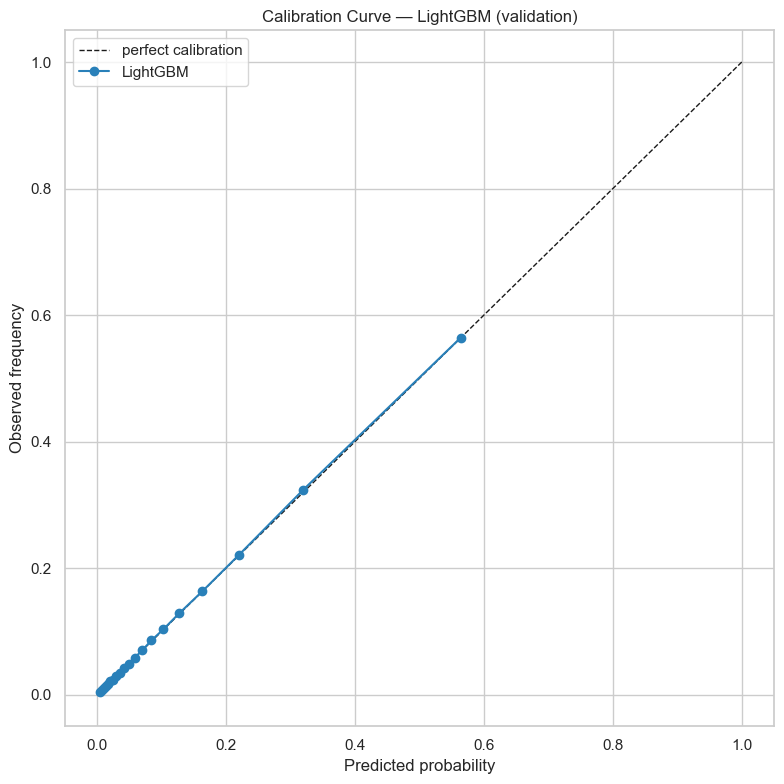

mean absolute calibration error: 0.0007


,predicted,observed,diff
0,0.0040,0.0041,0.0001
1,0.0071,0.0070,-0.0001
2,0.0099,0.0098,-0.0001
3,0.0129,0.0134,0.0005
4,0.0162,0.0161,-0.0001
5,0.0199,0.0207,0.0008
6,0.0241,0.0234,-0.0007
7,0.0290,0.0298,0.0008
8,0.0347,0.0343,-0.0004
9,0.0413,0.0426,0.0013


In [53]:
cal_true, cal_pred = calibration_curve(
    val_lgb['target'], val_lgb['proba'], n_bins=20, strategy='quantile'
)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='perfect calibration')
ax.plot(cal_pred, cal_true, 'o-', color="#2980b9", label='LightGBM')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Observed frequency')
ax.set_title('Calibration Curve — LightGBM (validation)')
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/10_calibration_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# Sapma olcumu: ortalama mutlak fark
mae_cal = np.abs(cal_true - cal_pred).mean()
print(f"mean absolute calibration error: {mae_cal:.4f}")

pd.DataFrame({'predicted': cal_pred.round(4), 'observed': cal_true.round(4),
              'diff': (cal_true - cal_pred).round(4)})

### 11. Kalibrasyon Eğrisi

Sorulan soru: model 0,70 dediğinde, o gruptaki ürünlerin gerçekten %70'i
alınıyor mu?

Yöntem: validation setindeki tahminler olasılığa göre 20 eşit büyüklükte
kutuya bölündü (quantile). Her kutuda modelin ortalama tahmini ile gerçek
alım oranı karşılaştırıldı. Mükemmel kalibrasyon 45 derecelik çizgi olur.

**Sonuç: model kalibre. Ortalama mutlak hata 0,0007.**

Yirmi kutunun tamamında sapma 0,0041'in altında. Birkaç örnek:

    modelin dedigi    gercekte olan    fark
        0,0413            0,0426      +0,0013
        0,1276            0,1289      +0,0012
        0,3188            0,3229      +0,0041
        0,5636            0,5639      +0,0003

**Neden bu kadar iyi çıktı — üç tasarım kararı:**

1. `objective='binary'` doğrudan olasılık üretmeyi hedefliyor.
2. Sınıf ağırlığı kullanılmadı. Plandaki uyarı buydu: ağırlık F1'i birkaç
   puan artırabilir ama olasılıkları bozar. Kullanılmadı, bozulmadı.
3. Erken durdurma metriği `binary_logloss`. Logloss olasılık kalitesini
   ölçtüğü için model doğrudan bu hedefe göre durduruldu.

**İsotonic regresyon uygulanmadı.** Planda "kalibre değilse düzeltme uygula"
yazıyordu; koşul gerçekleşmedi. 0,0007'lik hatayı düzeltmeye çalışmak
gereksiz karmaşıklık olurdu ve muhtemelen validation setine aşırı uyum
getirirdi.

**Bir gözlem:** En yüksek kutuda bile ortalama olasılık 0,56. Model hiçbir
ürün için 0,90 gibi bir tahmin üretmiyor. Bu, aday setinin doğasından
geliyor — kullanıcının geçmişte aldığı her ürün adaydır, ama bir sonraki
siparişte ortalama 6,3 tanesi alınır. Belirsizlik yapısal.

**Faz 4 için:** Olasılık bantları (bariz / artımsal / düşük) güvenle
kurulabilir. Bantların anlamlı olması olasılıkların gerçeği yansıtmasına
bağlıydı; ölçüldü ve yansıtıyor.

## Eşik optimizasyonu - iki yöntem

In [54]:
# Yontem 1: sabit esik (ince tarama)
fixed_rows = []
for th in np.arange(0.05, 0.41, 0.01):
    val_lgb['prediction'] = (val_lgb['proba'] >= th).astype(int)
    fixed_rows.append({'threshold': th, 'f1': user_f1(val_lgb)})

fixed_df = pd.DataFrame(fixed_rows)
best_fixed = fixed_df.loc[fixed_df['f1'].idxmax()]
print(f"fixed threshold best: {best_fixed['threshold']:.2f} -> F1 = {best_fixed['f1']:.4f}")

# Yontem 2: kullanici bazli esik
# Olasiliklarin toplami = o kullanicinin kac urun alacaginin tahmini
# Kalibre oldugu icin (MAE 0,0007) bu toplam guvenilir
val_lgb = val_lgb.sort_values(['user_id', 'proba'], ascending=[True, False])
val_lgb['rank'] = val_lgb.groupby('user_id').cumcount() + 1
expected_n = val_lgb.groupby('user_id')['proba'].sum()

user_rows = []
for mult in [0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]:
    n_items = np.ceil(expected_n * mult).astype(int).clip(lower=1)
    val_lgb['n_allowed'] = val_lgb['user_id'].map(n_items)
    val_lgb['prediction'] = (val_lgb['rank'] <= val_lgb['n_allowed']).astype(int)
    f1 = user_f1(val_lgb)
    avg_rec = val_lgb['prediction'].sum() / val_lgb['user_id'].nunique()
    user_rows.append({'multiplier': mult, 'f1': f1, 'avg_items': avg_rec})
    print(f"multiplier {mult:.1f}: F1 = {f1:.4f}  (avg {avg_rec:.1f} items)")

user_df = pd.DataFrame(user_rows)
best_user = user_df.loc[user_df['f1'].idxmax()]

print(f"\nfixed threshold:  F1 = {best_fixed['f1']:.4f}")
print(f"per-user threshold: F1 = {best_user['f1']:.4f}  (multiplier {best_user['multiplier']:.1f})")
print(f"gain: {best_user['f1'] - best_fixed['f1']:.4f}")

fixed threshold best: 0.18 -> F1 = 0.3712
multiplier 0.6: F1 = 0.3405  (avg 4.3 items)
multiplier 0.8: F1 = 0.3614  (avg 5.5 items)
multiplier 1.0: F1 = 0.3728  (avg 6.8 items)
multiplier 1.2: F1 = 0.3771  (avg 8.1 items)
multiplier 1.4: F1 = 0.3770  (avg 9.3 items)
multiplier 1.6: F1 = 0.3735  (avg 10.6 items)
multiplier 1.8: F1 = 0.3690  (avg 11.8 items)
multiplier 2.0: F1 = 0.3633  (avg 13.1 items)

fixed threshold:  F1 = 0.3712
per-user threshold: F1 = 0.3771  (multiplier 1.2)
gain: 0.0059


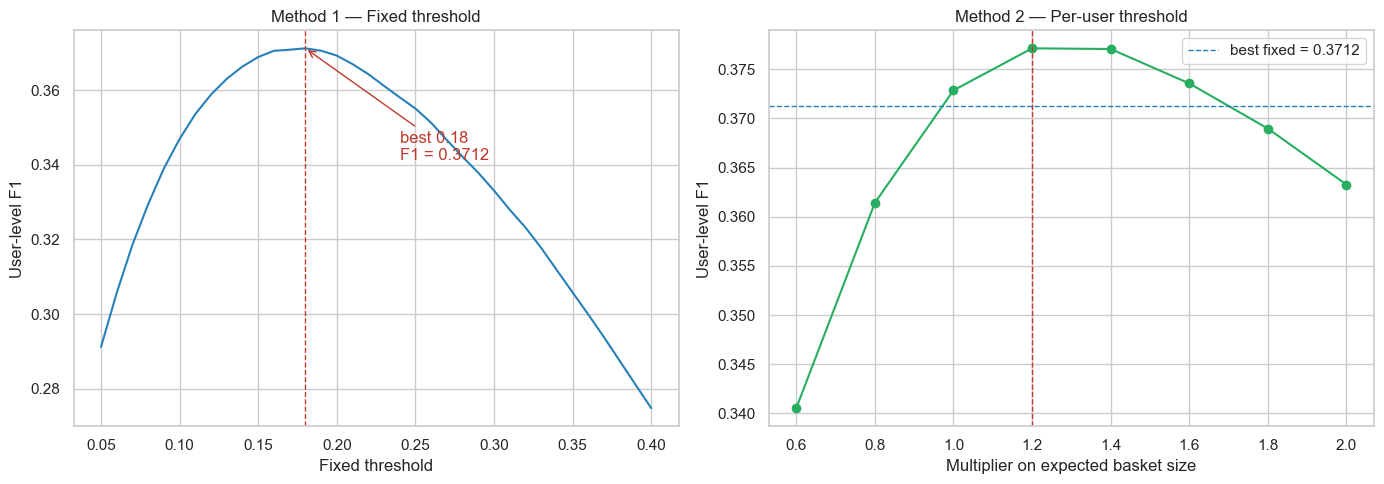

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fixed_df['threshold'], fixed_df['f1'], color="#2980b9")
axes[0].axvline(best_fixed['threshold'], color="#c0392b", linestyle='--', linewidth=1)
axes[0].annotate(f"best {best_fixed['threshold']:.2f}\nF1 = {best_fixed['f1']:.4f}",
                 xy=(best_fixed['threshold'], best_fixed['f1']),
                 xytext=(best_fixed['threshold'] + 0.06, best_fixed['f1'] - 0.03),
                 arrowprops=dict(arrowstyle='->', color="#c0392b"), color="#c0392b")
axes[0].set_xlabel('Fixed threshold')
axes[0].set_ylabel('User-level F1')
axes[0].set_title('Method 1 — Fixed threshold')

axes[1].plot(user_df['multiplier'], user_df['f1'], 'o-', color="#27ae60")
axes[1].axhline(best_fixed['f1'], color="#2980b9", linestyle='--', linewidth=1,
                label=f"best fixed = {best_fixed['f1']:.4f}")
axes[1].axvline(best_user['multiplier'], color="#c0392b", linestyle='--', linewidth=1)
axes[1].set_xlabel('Multiplier on expected basket size')
axes[1].set_ylabel('User-level F1')
axes[1].set_title('Method 2 — Per-user threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/figures/11_threshold_optimization.png", dpi=150, bbox_inches="tight")
plt.show()

### 12. Eşik Optimizasyonu — Sabit ve Kullanıcı Bazlı

Model olasılık üretiyor, biz ürün listesi vermek zorundayız. Aradaki karar
eşik. İki yöntem karşılaştırıldı.

**Yöntem 1 — Sabit eşik.** Herkese aynı kesme noktası. 0,05 ile 0,40 arası
0,01 adımlarla tarandı. En iyi: 0,18 → F1 = 0,3712, kullanıcı başına
ortalama 10,1 ürün.

**Yöntem 2 — Kullanıcı bazlı eşik.** Kullanıcının tüm ürün olasılıkları
toplanıyor; çıkan sayı o kullanıcının kaç ürün alacağının tahmini. Sonra en
yüksek olasılıklı o kadar ürün öneriliyor. Bu yaklaşım ancak olasılıklar
kalibreyse çalışır — bir önceki adımda ölçüldü (MAE 0,0007).

    carpan    F1        ort. urun
     0,8     0,3614       5,5
     1,0     0,3728       6,8
     1,2     0,3771       8,1     <- en iyi
     1,4     0,3770       9,3
     1,6     0,3735      10,6

**Kazanç: 0,0059** (0,3712 → 0,3771). Tavanın %53,1'inden %54,0'a.

**Kazanç nereden geliyor:** Sabit eşik, 30 ürün alan kullanıcıyla 4 ürün
alan kullanıcıya aynı kesme noktasını uyguluyor. Kullanıcı bazlı yöntem
her kullanıcının kendi beklentisine göre karar veriyor.

**Çarpanın 1,0 değil 1,2 çıkması:** Doğrudan olasılık toplamını kullanmak
(6,8 ürün) 0,3728 veriyor; %20 fazla önermek 0,3771. F1 biraz cömert
davranmayı ödüllendiriyor — kaçırılan bir ürünün maliyeti, fazladan
önerilen bir ürünün maliyetinden yüksek. Optimum geniş bir platoda
(1,2 ve 1,4 neredeyse eşit), yani seçim hassas değil.

**Kalibrasyonun ikinci doğrulaması:** Çarpan 1,0'da ortalama 6,8 ürün
öneriliyor. Ulaşılabilir pozitif ortalaması 6,3 (828.824 / 131.209).
Olasılık toplamı gerçek sayıyı neredeyse birebir tahmin ediyor.

In [56]:
def score_all(df, proba_col='proba'):
    """Tek bir tahmin setinin tum metriklerini dondurur."""
    f1 = user_f1(df)
    prec, rec = user_precision_recall(df)
    auc = roc_auc_score(df['target'], df[proba_col]) if proba_col in df else np.nan
    return {'user_f1': f1, 'precision': prec, 'recall': rec, 'auc': auc}


rows = []

# Baseline 0-4 (olasilik uretmiyorlar, AUC yok)
b = valid[['user_id', 'target']].copy()
b['prediction'] = 0
rows.append({'method': '0: predict nothing', **score_all(b)})

b['prediction'] = 1
rows.append({'method': '1: predict everything', **score_all(b)})

b2 = valid[['user_id', 'target', 'up_orders_since_last']].copy()
b2['prediction'] = (b2['up_orders_since_last'] == 0).astype(int)
rows.append({'method': '2: repeat last order', **score_all(b2)})

b3 = valid[['user_id', 'target', 'up_n_purchases']].copy()
b3['rank'] = b3.groupby('user_id')['up_n_purchases'].rank(method='first', ascending=False)
b3['prediction'] = (b3['rank'] <= 10).astype(int)
rows.append({'method': '3: top 10 most purchased', **score_all(b3)})

b4 = valid[['user_id', 'target', 'up_order_rate']].copy()
b4['prediction'] = (b4['up_order_rate'] >= 0.35).astype(int)
rows.append({'method': '4: order rate >= 0.35', **score_all(b4)})

# Logistic regression
val_lr['prediction'] = (val_lr['proba'] >= best_lr[0]).astype(int)
rows.append({'method': f'LR (fixed {best_lr[0]:.2f})', **score_all(val_lr)})

# LightGBM - sabit esik
val_lgb['prediction'] = (val_lgb['proba'] >= best_fixed['threshold']).astype(int)
rows.append({'method': f"LightGBM (fixed {best_fixed['threshold']:.2f})", **score_all(val_lgb)})

# LightGBM - kullanici bazli esik
n_items = np.ceil(expected_n * best_user['multiplier']).astype(int).clip(lower=1)
val_lgb['n_allowed'] = val_lgb['user_id'].map(n_items)
val_lgb['prediction'] = (val_lgb['rank'] <= val_lgb['n_allowed']).astype(int)
rows.append({'method': f"LightGBM (per-user x{best_user['multiplier']:.1f})", **score_all(val_lgb)})

final = pd.DataFrame(rows).sort_values('user_f1', ascending=False).reset_index(drop=True)
final['pct_of_ceiling'] = final['user_f1'] / 0.6986

final.round(4)

,method,user_f1,precision,recall,auc,pct_of_ceiling
0,LightGBM (per-user x1.2),0.3771,0.3542,0.4600,0.8378,0.5398
1,LightGBM (fixed 0.18),0.3712,0.3346,0.5082,0.8378,0.5314
2,LR (fixed 0.15),0.3594,0.3029,0.5478,0.8267,0.5145
3,4: order rate >= 0.35,0.3178,0.2408,0.6153,NaN,0.4549
4,2: repeat last order,0.3123,0.2873,0.4283,NaN,0.4471
5,3: top 10 most purchased,0.3068,0.2754,0.4844,NaN,0.4391
6,1: predict everything,0.2153,0.1318,0.9344,NaN,0.3082
7,0: predict nothing,0.0000,0.0000,0.0000,NaN,0.0000


### 13. Karşılaştırma Tablosu — Tüm Yöntemler

Tüm yöntemler aynı validation setinde, aynı `user_f1` fonksiyonuyla ölçüldü.
Sayılar doğrudan karşılaştırılabilir.

    yontem                        F1      precision  recall   AUC     tavanin %
    LightGBM (per-user x1,2)    0,3771     0,3542   0,4600  0,8378     %54,0
    LightGBM (fixed 0,18)       0,3712     0,3346   0,5082  0,8378     %53,1
    LR (fixed 0,15)             0,3594     0,3029   0,5478  0,8267     %51,5
    4: order rate >= 0,35       0,3178     0,2408   0,6153     —       %45,5
    2: repeat last order        0,3123     0,2873   0,4283     —       %44,7
    3: top 10 most purchased    0,3068     0,2754   0,4844     —       %43,9
    1: predict everything       0,2153     0,1318   0,9344     —       %30,8
    0: predict nothing          0,0000     0,0000   0,0000     —        %0

**Precision/recall kolonları F1'in neden tek başına yetmediğini gösteriyor.**

Baseline 1'in recall'ı 0,9344 — neredeyse tüm doğru ürünleri yakalıyor.
Ama precision 0,1318, yani listenin %87'si boşa gidiyor. Sadece recall'a
bakan bir değerlendirme bu yöntemi en iyi ilan ederdi.

Baseline 4'ün recall'ı (0,6153) tüm modellerden yüksek. Çok ürün önererek
recall topluyor, precision'dan kaybediyor.

**İki LightGBM versiyonu arasındaki fark:**

    sabit esik:        precision 0,3346  /  recall 0,5082
    kullanici bazli:   precision 0,3542  /  recall 0,4600

Kullanıcı bazlı eşik recall'dan feragat edip precision kazanıyor. Net etki
pozitif (+0,0059 F1): daha az ama daha isabetli öneri.

**AUC eşikten bağımsız.** Modelin sıralama kalitesini ölçüyor — "doğru
ürünler yanlışların üstünde mi?" İki LightGBM satırında AUC aynı (0,8378),
çünkü model aynı, yalnızca kesme noktası farklı.

**LR ile LightGBM

In [57]:
# TEST SETI — tek olcum, hicbir karar burada alinmaz
# Esik (0,18) ve carpan (1,2) validation'dan geldi, burada arama YOK

test_lgb = test[['user_id', 'target']].copy()
test_lgb['proba'] = model.predict(test[LGB_FEATURES], num_iteration=model.best_iteration)

# Sabit esik
test_lgb['prediction'] = (test_lgb['proba'] >= best_fixed['threshold']).astype(int)
test_fixed = score_all(test_lgb)

# Kullanici bazli esik
test_lgb = test_lgb.sort_values(['user_id', 'proba'], ascending=[True, False])
test_lgb['rank'] = test_lgb.groupby('user_id').cumcount() + 1
test_expected = test_lgb.groupby('user_id')['proba'].sum()
test_n = np.ceil(test_expected * best_user['multiplier']).astype(int).clip(lower=1)
test_lgb['n_allowed'] = test_lgb['user_id'].map(test_n)
test_lgb['prediction'] = (test_lgb['rank'] <= test_lgb['n_allowed']).astype(int)
test_peruser = score_all(test_lgb)

test_table = pd.DataFrame([
    {'set': 'validation', 'method': 'fixed 0.18', **{k: v for k, v in final.iloc[1].items() if k != 'method' and k != 'set' and k != 'pct_of_ceiling'}},
    {'set': 'test', 'method': 'fixed 0.18', **test_fixed},
    {'set': 'validation', 'method': 'per-user x1.2', **{k: v for k, v in final.iloc[0].items() if k != 'method' and k != 'set' and k != 'pct_of_ceiling'}},
    {'set': 'test', 'method': 'per-user x1.2', **test_peruser},
])

test_table.round(4)

,set,method,user_f1,precision,recall,auc
0,validation,fixed 0.18,0.3712,0.3346,0.5082,0.8378
1,test,fixed 0.18,0.3730,0.3366,0.5094,0.8365
2,validation,per-user x1.2,0.3771,0.3542,0.4600,0.8378
3,test,per-user x1.2,0.3777,0.3545,0.4611,0.8365


### 14. Test Seti — Nihai Ölçüm

Test seti (19.681 kullanıcı, 1,26M satır) bu ana kadar hiç kullanılmadı.
Eşik (0,18) ve çarpan (1,2) validation setinden geldi; burada hiçbir arama
veya ayar yapılmadı. Tek seferlik doğrulama ölçümü.

    set          yontem          F1      precision  recall   AUC
    validation   fixed 0,18    0,3712     0,3346   0,5082  0,8378
    test         fixed 0,18    0,3730     0,3366   0,5094  0,8365
    validation   per-user x1,2 0,3771     0,3542   0,4600  0,8378
    test         per-user x1,2 0,3777     0,3545   0,4611  0,8365

**Farklar gürültü seviyesinde:** sabit eşikte +0,0018, kullanıcı bazlı
eşikte +0,0006. Test skorunun validation'dan hafifçe yüksek olması
tesadüfi dalgalanma.

**Ne kanıtlıyor:**

1. Model aşırı öğrenmemiş. Erken durdurma (553 tur) doğru noktada kesmiş.
2. Validation'da yapılan eşik seçimi o sete özel bir tesadüfe dayanmıyor;
   aynı parametreler görülmemiş kullanıcılarda da çalışıyor.
3. Üçlü bölme kararı işe yaradı. Tek validation setiyle çalışılsaydı
   eşik o sette optimize edilip yine orada raporlanacaktı — sayı iyimser
   çıkardı ve doğrulanamazdı.

**NİHAİ SONUÇ: user-level F1 = 0,3777**

    ulasilabilir tavan           0,6986   (%100)
    LightGBM + kullanici esigi   0,3777    %54,1
    en iyi baseline              0,3178    %45,5
    hicbir sey onerme            0,0000     %0

Model, basit kuralların üzerine 0,0599 ekliyor — tavanın %8,6'sı kadar
bir kazanç. Bu dürüst sonuç: 50 özellik, 553 ağaç ve iki aşamalı eşik
optimizasyonunun toplam katkısı, "son sepeti aynen tekrarla" kuralının
üzerine altı puan.

**Test seti bundan sonra kullanılmayacak.** Faz 4'teki etki analizi
validation seti üzerinde kurulacak.

# Olasılık bantları

In [58]:
# Bant sinirlarini belirlemeden önce olsalilik dagilimlarina bakıyoruz
val_bands = val_lgb[['user_id', 'target', 'proba']].copy()

print(val_bands['proba'].describe().round(4))
print()
for qt in [0.5, 0.75, 0.90, 0.95, 0.99]:
    print(f"{qt:.0%} quantile: {val_bands['proba'].quantile(qt):.4f}")
print()
for th in [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]:
    n = (val_bands['proba'] >= th).sum()
    rate = val_bands.loc[val_bands['proba'] >= th, 'target'].mean()
    print(f"proba >= {th:.2f}: {n:>9,} rows ({n/len(val_bands):.1%}), actual purchase rate = {rate:.3f}")

count    1.267091e+06
mean     9.780000e-02
std      1.362000e-01
min      7.000000e-04
25%      1.800000e-02
50%      4.500000e-02
75%      1.139000e-01
max      9.536000e-01
Name: proba, dtype: float64

50% quantile: 0.0450
75% quantile: 0.1139
90% quantile: 0.2582
95% quantile: 0.3977
99% quantile: 0.6809

proba >= 0.05:   595,095 rows (47.0%), actual purchase rate = 0.185
proba >= 0.10:   355,972 rows (28.1%), actual purchase rate = 0.261
proba >= 0.20:   175,654 rows (13.9%), actual purchase rate = 0.383
proba >= 0.30:   102,085 rows (8.1%), actual purchase rate = 0.482
proba >= 0.40:    62,652 rows (4.9%), actual purchase rate = 0.566
proba >= 0.50:    38,219 rows (3.0%), actual purchase rate = 0.643
proba >= 0.60:    21,919 rows (1.7%), actual purchase rate = 0.713
proba >= 0.70:    10,900 rows (0.9%), actual purchase rate = 0.781


In [59]:
# Olasilik bantlari — sinirlar 0,10 ve 0,50
def make_bands(df, low=0.10, high=0.50):
    return pd.cut(df['proba'], bins=[0, low, high, 1.0],
                  labels=['low', 'incremental', 'obvious'], include_lowest=True)

val_bands['band'] = make_bands(val_bands)

# Her bandin buyuklugu ve gercek alim orani
band_summary = val_bands.groupby('band', observed=True).agg(
    n_rows=('target', 'size'),
    n_purchased=('target', 'sum'),
    actual_rate=('target', 'mean'),
    avg_proba=('proba', 'mean'),
).reset_index()

band_summary['pct_of_rows'] = band_summary['n_rows'] / len(val_bands)
band_summary['pct_of_purchases'] = band_summary['n_purchased'] / val_bands['target'].sum()

band_summary.round(4)

,band,n_rows,n_purchased,actual_rate,avg_proba,pct_of_rows,pct_of_purchases
0,low,911119,31727,0.0348,0.0346,0.7191,0.2547
1,incremental,317753,68262,0.2148,0.2137,0.2508,0.5479
2,obvious,38219,24590,0.6434,0.6414,0.0302,0.1974


In [60]:
# Duyarlilik kontrolu: sinirlar degisince ana bulgu degisiyor mu
sens_rows = []
for low, high in [(0.10, 0.50), (0.15, 0.40), (0.05, 0.60), (0.10, 0.40)]:
    tmp = val_bands[['target', 'proba']].copy()
    tmp['band'] = make_bands(tmp, low=low, high=high)
    g = tmp.groupby('band', observed=True).agg(
        n_rows=('target', 'size'), n_purchased=('target', 'sum')
    )
    total_pur = tmp['target'].sum()
    sens_rows.append({
        'bounds': f'{low:.2f} / {high:.2f}',
        'obvious_pct_rows': g.loc['obvious', 'n_rows'] / len(tmp),
        'obvious_pct_purchases': g.loc['obvious', 'n_purchased'] / total_pur,
        'incremental_pct_rows': g.loc['incremental', 'n_rows'] / len(tmp),
        'incremental_pct_purchases': g.loc['incremental', 'n_purchased'] / total_pur,
    })

pd.DataFrame(sens_rows).round(4)

,bounds,obvious_pct_rows,obvious_pct_purchases,incremental_pct_rows,incremental_pct_purchases
0,0.10 / 0.50,0.0302,0.1974,0.2508,0.5479
1,0.15 / 0.40,0.0494,0.2846,0.1412,0.3479
2,0.05 / 0.60,0.0173,0.1255,0.4524,0.7580
3,0.10 / 0.40,0.0494,0.2846,0.2315,0.4607


### 15. Olasılık Bantları

Tahminler üç banda ayrıldı. Amaç şu soruyu cevaplamak: modelin doğru
tahminlerinin ne kadarı "zaten olacak" durumlardan geliyor?

Sınırlar 0,10 ve 0,50. Üst sınırın anlamı doğal: model o ürünü alma
ihtimalini yarıdan fazla görüyor.

    bant          satir payi   alimlarin payi   gercek alim orani
    obvious          %3,0          %19,7             0,643
    incremental     %25,1          %54,8             0,215
    low             %71,9          %25,5             0,035

**Planın öngörüsü gerçekleşmedi — tersi çıktı.**

Plan şöyle diyordu: "Modelin doğru tahminlerinin büyük kısmı bariz bantta
olacak; yani yüksek F1'in çoğu zaten olacak şeyi tahmin etmekten geliyor."

Gerçekte alınan ürünlerin yalnızca %19,7'si bariz bantta. %54,8'i modelin
kararsız olduğu artımsal bantta.

**Sebep:** Model hiçbir tahminde çok emin değil. Bariz bant tüm tahminlerin
sadece %3'ü. Bu, kalibrasyon eğrisinde de görünüyordu — en yüksek kutunun
ortalaması 0,56. Belirsizlik yapısal: kullanıcının geçmişte aldığı her ürün
aday sayılıyor, ama bir sonraki siparişte ortalama 6,3 tanesi alınıyor.

**Duyarlılık kontrolü — bulgu sınır seçimine bağlı mı:**

    sinirlar        bariz bandin alimlardaki payi
    0,05 / 0,60              %12,6
    0,10 / 0,50              %19,7
    0,10 / 0,40              %28,5
    0,15 / 0,40              %28,5

Bariz bandın payı %12,6 ile %28,5 arasında değişiyor ama hiçbir senaryoda
çoğunluğa yaklaşmıyor. En cömert sınırda bile alımların %71,5'i bariz
bandın dışında. Ana bulgu sınır seçiminden bağımsız.

**Düşük bantta kaçırılanlar:** 31.727 ürün (alımların %25,5'i) modelin
"almayacak" dediği halde alınmış. Recall kaybının büyük kısmı burada ve bu
grup mevcut özelliklerle yakalanamıyor.

**İş açısından anlamı:** Fırsat alanı sanıldığından büyük. Bir öneri
sistemi yalnızca artımsal bantta çalışsa gerçek alımların yarısından
fazlasına dokunabilir. Ancak bu bandın alım oranı %21,5 — buradaki her
öneri belirsiz bir bahis. Önerinin gerçekten fark yaratıp yaratmadığı
sonraki adımda test edilecek.

## Artımsal alanın büyüklüğü

In [61]:
# Artimsal bant icinde model hala ayirt edebiliyor mu
inc = val_bands[val_bands['band'] == 'incremental'].copy()
inc['decile'] = pd.qcut(inc['proba'], 10, labels=False) + 1

inc_detail = inc.groupby('decile').agg(
    n_rows=('target', 'size'),
    avg_proba=('proba', 'mean'),
    actual_rate=('target', 'mean'),
).reset_index()

print(f"incremental band: {len(inc):,} rows, {inc['target'].sum():,} purchases")
print(f"AUC within band: {roc_auc_score(inc['target'], inc['proba']):.4f}")
print(f"lift (top decile / bottom decile): {inc_detail['actual_rate'].iloc[-1] / inc_detail['actual_rate'].iloc[0]:.2f}x\n")

inc_detail.round(4)

incremental band: 317,753 rows, 68,262 purchases
AUC within band: 0.6643
lift (top decile / bottom decile): 4.12x



,decile,n_rows,avg_proba,actual_rate
0,1,31776,0.1054,0.1053
1,2,31775,0.1173,0.1180
2,3,31775,0.1313,0.1359
3,4,31775,0.1482,0.1448
4,5,31776,0.1688,0.1707
5,6,31775,0.1950,0.1963
6,7,31775,0.2286,0.2282
7,8,31775,0.2729,0.2783
8,9,31775,0.3363,0.3370
9,10,31776,0.4332,0.4338


In [62]:
# Artimsal alanin buyuklugu — kullanici basina ve toplam
n_users_val = val_bands['user_id'].nunique()

inc_per_user = inc.groupby('user_id').size()
top3 = inc[inc['decile'] >= 8]

print(f"validation users: {n_users_val:,}")
print(f"incremental pairs: {len(inc):,} ({len(inc)/n_users_val:.1f} per user)")
print(f"  of which purchased: {inc['target'].sum():,} ({inc['target'].mean():.1%})")
print(f"users with at least one incremental pair: {inc_per_user.count():,} ({inc_per_user.count()/n_users_val:.1%})")
print()
print(f"top 3 deciles of incremental band: {len(top3):,} pairs ({len(top3)/n_users_val:.1f} per user)")
print(f"  actual purchase rate: {top3['target'].mean():.1%}")
print(f"  share of all purchases: {top3['target'].sum()/val_bands['target'].sum():.1%}")

validation users: 19,681
incremental pairs: 317,753 (16.1 per user)
  of which purchased: 68,262 (21.5%)
users with at least one incremental pair: 19,423 (98.7%)

top 3 deciles of incremental band: 95,326 pairs (4.8 per user)
  actual purchase rate: 35.0%
  share of all purchases: 26.8%


### 16. Artımsal Alanın Büyüklüğü

Artımsal bant alımların %54,8'ini içeriyor ama alım oranı %21,5. Soru: model
bu bandın içinde hâlâ ayırt edebiliyor mu, yoksa orada kör mü?

**Bant içi AUC = 0,6643.** Kör değil (0,50 rastgele olurdu). Bant kendi
içinde on dilime bölündüğünde:

    dilim   ortalama olasilik   gercek alim orani
      1           0,105              0,105
      5           0,169              0,171
     10           0,433              0,434

En üst dilim ile en alt dilim arasında **4,12 kat** fark. "Belirsiz"
dediğimiz bant kendi içinde oldukça heterojen.

**Kalibrasyonun üçüncü doğrulaması:** Her dilimde `avg_proba` ile
`actual_rate` neredeyse birebir aynı (0,1054 vs 0,1053; 0,2729 vs 0,2783;
0,4332 vs 0,4338). Bantlara güvenilebileceğinin kanıtı.

**Ölçek:**

    artimsal bant toplam         317.753 cift   (16,1 / kullanici)
    en az bir cifti olan kullanici  19.423      (%98,7)
    ust 3 dilim                   95.326 cift   (4,8 / kullanici)
      alim orani                     %35,0
      tum alimlardaki payi           %26,8

**Yorum:** Kullanıcıların neredeyse tamamında belirsiz ürün var, ancak 16
ürün önermek pratik değil. Üst 3 dilime inildiğinde kullanıcı başına 4,8
çift kalıyor — gerçekçi bir öneri kotasına (5 slot) uyuyor — ve bu alan tüm
alımların %26,8'ini kapsıyor.

Karşılaştırma: bariz bant alımların %19,7'si ve kullanıcı başına yalnızca
1,9 çift. Artımsal bandın üst dilimleri hem daha büyük hem daha belirsiz.

**Kritik sınır:** Buraya kadar olan her şey korelasyon. "Bu bantta öneri
fark yaratır" cümlesi henüz kanıtlanmadı — veride öneri diye bir şey yok.
Sonraki adım, bir müdahalenin sonucu gerçekten etkileyip etkilemediğini
test edecek.

## Eşleştirme analizi

In [63]:
# Mudahale: urun son prior siparistte var miydi (up_orders_since_last == 0)
# Sonuc: urun train siparisinde var mi (target)
# up_orders_since_last ve up_last5_purchases eslestirme degiskeni DEGIL —
# ikisi de mudahaleyi dogrudan belirliyor, ortak destek kalmaz
MATCH_COLS = ['up_n_purchases', 'up_order_rate', 'up_share_of_orders',
              'u_n_orders', 'u_reorder_rate', 'p_reorder_rate', 'up_first_order']

m = valid[['user_id', 'product_id', 'target', 'up_orders_since_last'] + MATCH_COLS].copy()
m['treated'] = (m['up_orders_since_last'] == 0).astype(int)

raw = m.groupby('treated')['target'].agg(['size', 'mean'])
print("raw difference (no matching):")
print(raw.round(4))
print(f"\ndifference: {raw.loc[1, 'mean'] - raw.loc[0, 'mean']:.4f}")
print()

print("covariate means by group:")
print(m.groupby('treated')[MATCH_COLS].mean().round(3).T)

raw difference (no matching):
            size    mean
treated                 
0        1063867  0.0632
1         203224  0.2820

difference: 0.2188

covariate means by group:
treated                  0       1
up_n_purchases       2.163   3.959
up_order_rate        0.206   0.768
up_share_of_orders   0.124   0.310
u_n_orders          27.194  16.272
u_reorder_rate       0.512   0.450
p_reorder_rate       0.526   0.579
up_first_order      11.065   9.022


In [64]:
# Egilim skoru: her ciftin mudahale gorme olasiligi
from sklearn.ensemble import HistGradientBoostingClassifier

X_ps = m[MATCH_COLS].to_numpy(dtype='float32')
y_ps = m['treated'].to_numpy()

ps_model = HistGradientBoostingClassifier(
    max_iter=100, learning_rate=0.1, max_leaf_nodes=31, random_state=42
)
ps_model.fit(X_ps, y_ps)
m['ps'] = ps_model.predict_proba(X_ps)[:, 1]

print(f"propensity score AUC: {roc_auc_score(y_ps, m['ps']):.4f}\n")
print("propensity score distribution by group:")
print(m.groupby('treated')['ps'].describe(percentiles=[0.05, 0.5, 0.95]).round(4))

propensity score AUC: 0.9681

propensity score distribution by group:
             count    mean     std     min      5%     50%     95%     max
treated                                                                   
0        1063867.0  0.0554  0.1144  0.0000  0.0000  0.0000  0.2988  0.9352
1         203224.0  0.7099  0.3465  0.0043  0.1028  0.9995  0.9999  1.0000


In [65]:
for lo, hi in [(0.05, 0.95), (0.10, 0.90), (0.20, 0.80)]:
    sub = m[(m['ps'] >= lo) & (m['ps'] <= hi)]
    n_t = (sub['treated'] == 1).sum()
    n_c = (sub['treated'] == 0).sum()
    print(f"ps in [{lo:.2f}, {hi:.2f}]: {len(sub):>8,} rows  "
          f"(treated {n_t:>7,} / control {n_c:>7,})  "
          f"= {len(sub)/len(m):.1%} of all pairs")

ps in [0.05, 0.95]:  378,681 rows  (treated  92,608 / control 286,073)  = 29.9% of all pairs
ps in [0.10, 0.90]:  276,351 rows  (treated  82,598 / control 193,753)  = 21.8% of all pairs
ps in [0.20, 0.80]:  164,731 rows  (treated  64,578 / control 100,153)  = 13.0% of all pairs


In [66]:
from sklearn.neighbors import NearestNeighbors

PS_LO, PS_HI = 0.10, 0.90
sub = m[(m['ps'] >= PS_LO) & (m['ps'] <= PS_HI)].copy()

treated = sub[sub['treated'] == 1].reset_index(drop=True)
control = sub[sub['treated'] == 0].reset_index(drop=True)

# Her mudahale goren cift icin en yakin skorlu kontrol ciftini bul
nn = NearestNeighbors(n_neighbors=1).fit(control[['ps']].to_numpy())
dist, idx = nn.kneighbors(treated[['ps']].to_numpy())

# Caliper: skor farki 0,01'den buyukse eslestirmeyi reddet
CALIPER = 0.01
keep = dist.ravel() <= CALIPER

matched_t = treated[keep].reset_index(drop=True)
matched_c = control.iloc[idx.ravel()[keep]].reset_index(drop=True)

print(f"treated in support: {len(treated):,}")
print(f"matched pairs:      {len(matched_t):,} ({keep.mean():.1%} of treated)")
print(f"mean ps distance:   {dist.ravel()[keep].mean():.5f}")

treated in support: 82,598
matched pairs:      82,598 (100.0% of treated)
mean ps distance:   0.00001


In [67]:
# Eslestirme kalitesi: standartlastirilmis fark (SMD)
# Kural: |SMD| < 0,10 iyi dengelenmis sayilir
def smd(a, b):
    pooled_sd = np.sqrt((a.var() + b.var()) / 2)
    return (a.mean() - b.mean()) / pooled_sd if pooled_sd > 0 else 0.0

bal_rows = []
for col in MATCH_COLS + ['ps']:
    before = smd(m.loc[m['treated'] == 1, col], m.loc[m['treated'] == 0, col])
    after = smd(matched_t[col], matched_c[col])
    bal_rows.append({
        'covariate': col,
        'smd_before': before,
        'smd_after': after,
        'improved': abs(after) < abs(before),
    })

balance = pd.DataFrame(bal_rows)
print(f"covariates with |SMD| < 0.10 after matching: "
      f"{(balance['smd_after'].abs() < 0.10).sum()} / {len(balance)}\n")
balance.round(4)

covariates with |SMD| < 0.10 after matching: 8 / 8



,covariate,smd_before,smd_after,improved
0,up_n_purchases,0.3920,0.0299,True
1,up_order_rate,2.3695,-0.0161,True
2,up_share_of_orders,0.9576,-0.0235,True
3,u_n_orders,-0.5413,0.0648,True
4,u_reorder_rate,-0.3061,0.0328,True
5,p_reorder_rate,0.3316,-0.0062,True
6,up_first_order,-0.1588,0.0505,True
7,ps,2.5365,0.0000,True


In [68]:
# Eslestirilmis grupta sonuc farki
rate_t = matched_t['target'].mean()
rate_c = matched_c['target'].mean()
att = rate_t - rate_c

# Standart hata ve guven araligi
n = len(matched_t)
se = np.sqrt(rate_t * (1 - rate_t) / n + rate_c * (1 - rate_c) / n)
ci_lo, ci_hi = att - 1.96 * se, att + 1.96 * se

raw_diff = raw.loc[1, 'mean'] - raw.loc[0, 'mean']

print(f"matched pairs:        {n:,}\n")
print(f"treated group rate:   {rate_t:.4f}")
print(f"control group rate:   {rate_c:.4f}")
print(f"ATT (matched):        {att:.4f}  [95% CI: {ci_lo:.4f}, {ci_hi:.4f}]")
print(f"\nraw difference:       {raw_diff:.4f}")
print(f"reduction:            {(1 - att/raw_diff):.1%} of the raw difference was confounding")

matched pairs:        82,598

treated group rate:   0.3766
control group rate:   0.2632
ATT (matched):        0.1133  [95% CI: 0.1089, 0.1178]

raw difference:       0.2188
reduction:            48.2% of the raw difference was confounding


### 17. Eşleştirme Analizi

**Soru:** Bir ürünün son siparişte sepette olması, bir sonraki siparişte
alınmasına sebep mi oluyor? Yoksa sadece "bu kullanıcı bu ürünü sık alıyor"
bilgisinin göstergesi mi?

Müdahale: `up_orders_since_last == 0` (ürün son prior siparişte vardı)
Sonuç: `target` (ürün train siparişinde var mı)

**Ham fark: 0,2188** (müdahale grubu %28,2 / kontrol %6,3)

Bu sayı olduğu gibi yorumlanamaz, çünkü iki grup baştan çok farklı:

    degisken              mudahale yok   mudahale var
    up_order_rate             0,206         0,768
    up_share_of_orders        0,124         0,310
    up_n_purchases            2,16          3,96
    u_n_orders               27,19         16,27

Son siparişte olan ürünler, kullanıcının siparişlerinin %77'sinde alınan
ürünler; olmayan grup %21. Karşılaştırma kirli.

**Eşleştirme değişkenleri.** `up_orders_since_last` ve `up_last5_purchases`
bilerek dışarıda bırakıldı — ikisi de müdahaleyi doğrudan belirliyor, dahil
edilse ortak destek tamamen kaybolurdu.

**Ortak destek sorunu.** Eğilim skoru modelinin AUC'si 0,9681 çıktı. Müdahale
neredeyse tamamen bu değişkenler tarafından belirleniyor:

    grup            medyan egilim skoru
    mudahale yok         0,0000
    mudahale var         0,9995

İki grup skor ekseninin iki ucunda. Çakışma bölgesi [0,10 - 0,90] alındı:
276.351 çift, tüm çiftlerin %21,8'i. Bu dürüst bir daraltma — sonuç "tüm
çiftler" için değil, "müdahale görüp görmeyeceği belirsiz çiftler" için
geçerli.

**Eşleştirme kalitesi (atlanamaz kontrol).** 82.598 müdahale çiftinin
tamamı, skor farkı 0,01'in altında kalan bir kontrol çiftiyle eşleşti.
Standartlaştırılmış fark (SMD) ile denge ölçüldü — kural |SMD| < 0,10:

    degisken              SMD once    SMD sonra
    up_order_rate          2,3695      -0,0161
    up_share_of_orders     0,9576      -0,0235
    u_n_orders            -0,5413       0,0648
    up_n_purchases         0,3920       0,0299

Sekiz değişkenin sekizi de eşik altına indi. Eşleştirme işini yaptı.

**SONUÇ:**

    eslestirilmis mudahale grubu    %37,7
    eslestirilmis kontrol grubu     %26,3
    ATT                             0,1133   [%95 GA: 0,1089 - 0,1178]

    ham fark                        0,2188
    karisma payi                    0,1055   (%48,2)

**Ham farkın neredeyse yarısı karışmaymış.** Benzer alım geçmişine sahip
iki üründen son siparişte olanın tekrar alınma oranı %37,7, olmayanın
%26,3.

**Bu henüz nedensellik değil.** Eşleştirme yalnızca ölçülebilen değişkenleri
dengeler. Ölçemediğimiz bir faktör — kullanıcının o dönem bir tarif
denemesi, evde bir ürünün bitmesi — hem son siparişte olmayı hem sonraki
siparişte alınmayı birlikte açıklıyor olabilir. Sonraki iki adım bunu
sınayacak.

## Placebo testi (negatif kontrol)

In [69]:
# Placebo sonuc: urun SONDAN BIR ONCEKI prior siparistte var miydi
# Mudahale gecmisi etkileyemez -> eslestirme dogruysa fark sifira yakin olmali
placebo_raw = q("""
with last_two as (
  select
    user_id,
    max(order_number) as last_n,
    max(order_number) - 1 as prev_n
  from `deneme-505002.instacart_clean.orders_prior`
  group by user_id
),
in_prev as (
  select distinct e.user_id, e.product_id
  from `deneme-505002.instacart_clean.order_products_enriched` e
  join last_two t
    on e.user_id = t.user_id and e.order_number = t.prev_n
)
select user_id, product_id, 1 as in_prev_order
from in_prev
""")

print(f"rows fetched: {len(placebo_raw):,}")
placebo_raw.head()

/Users/cemkulekci/anaconda3/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


rows fetched: 2,114,926


,user_id,product_id,in_prev_order
0,27073,4989,1
1,27073,3749,1
2,27073,26635,1
3,27073,8414,1
4,27073,39928,1


In [70]:
# Placebo sonucu eslestirilmis gruplara bagla
prev_lookup = placebo_raw.set_index(['user_id', 'product_id'])['in_prev_order']

def attach_placebo(df):
    out = df.copy()
    keys = pd.MultiIndex.from_arrays([out['user_id'], out['product_id']])
    out['placebo'] = prev_lookup.reindex(keys).fillna(0).to_numpy().astype(int)
    return out

mt = attach_placebo(matched_t)
mc = attach_placebo(matched_c)

p_rate_t = mt['placebo'].mean()
p_rate_c = mc['placebo'].mean()
placebo_effect = p_rate_t - p_rate_c

n = len(mt)
p_se = np.sqrt(p_rate_t * (1 - p_rate_t) / n + p_rate_c * (1 - p_rate_c) / n)
p_lo, p_hi = placebo_effect - 1.96 * p_se, placebo_effect + 1.96 * p_se

print("PLACEBO TEST — outcome that precedes the treatment")
print(f"treated group:   {p_rate_t:.4f}")
print(f"control group:   {p_rate_c:.4f}")
print(f"placebo effect:  {placebo_effect:.4f}  [95% CI: {p_lo:.4f}, {p_hi:.4f}]")
print()
print(f"real effect (ATT):  {att:.4f}")
print(f"placebo / real:     {abs(placebo_effect)/att:.1%}")

PLACEBO TEST — outcome that precedes the treatment
treated group:   0.3519
control group:   0.5089
placebo effect:  -0.1570  [95% CI: -0.1618, -0.1523]

real effect (ATT):  0.1133
placebo / real:     138.6%


In [71]:
# Eslestirme v2: ritim degiskenleri eklendi
MATCH_COLS2 = MATCH_COLS + ['up_avg_repeat_gap', 'up_days_since_last',
                            'up_avg_cart_position', 'u_avg_gap', 'u_sd_gap']

m2 = valid[['user_id', 'product_id', 'target', 'up_orders_since_last'] + MATCH_COLS2].copy()
m2['treated'] = (m2['up_orders_since_last'] == 0).astype(int)

X_ps2 = m2[MATCH_COLS2].to_numpy(dtype='float32')
y_ps2 = m2['treated'].to_numpy()

ps_model2 = HistGradientBoostingClassifier(
    max_iter=100, learning_rate=0.1, max_leaf_nodes=31, random_state=42
)
ps_model2.fit(X_ps2, y_ps2)
m2['ps'] = ps_model2.predict_proba(X_ps2)[:, 1]

print(f"propensity score AUC (v2): {roc_auc_score(y_ps2, m2['ps']):.4f}")

sub2 = m2[(m2['ps'] >= PS_LO) & (m2['ps'] <= PS_HI)].copy()
treated2 = sub2[sub2['treated'] == 1].reset_index(drop=True)
control2 = sub2[sub2['treated'] == 0].reset_index(drop=True)
print(f"common support: {len(sub2):,} rows (treated {len(treated2):,} / control {len(control2):,})")

nn2 = NearestNeighbors(n_neighbors=1).fit(control2[['ps']].to_numpy())
dist2, idx2 = nn2.kneighbors(treated2[['ps']].to_numpy())
keep2 = dist2.ravel() <= CALIPER

matched_t2 = treated2[keep2].reset_index(drop=True)
matched_c2 = control2.iloc[idx2.ravel()[keep2]].reset_index(drop=True)
print(f"matched pairs: {len(matched_t2):,} ({keep2.mean():.1%} of treated)")

propensity score AUC (v2): 0.9980
common support: 88,305 rows (treated 46,994 / control 41,311)
matched pairs: 46,994 (100.0% of treated)


In [72]:
# v2 dengeleme kontrolu
bal2 = []
for col in MATCH_COLS2:
    before = smd(m2.loc[m2['treated'] == 1, col], m2.loc[m2['treated'] == 0, col])
    after = smd(matched_t2[col], matched_c2[col])
    bal2.append({'covariate': col, 'smd_before': before, 'smd_after': after})
bal2 = pd.DataFrame(bal2)
print(f"balanced (|SMD| < 0.10): {(bal2['smd_after'].abs() < 0.10).sum()} / {len(bal2)}")
print(bal2.round(4).to_string(index=False))
print()

# v2 placebo testi
mt2 = attach_placebo(matched_t2)
mc2 = attach_placebo(matched_c2)

p2_t, p2_c = mt2['placebo'].mean(), mc2['placebo'].mean()
placebo2 = p2_t - p2_c

# v2 gercek etki
r2_t, r2_c = matched_t2['target'].mean(), matched_c2['target'].mean()
att2 = r2_t - r2_c
n2 = len(matched_t2)
se2 = np.sqrt(r2_t*(1-r2_t)/n2 + r2_c*(1-r2_c)/n2)

print("                      v1 (no rhythm)   v2 (with rhythm)")
print(f"matched pairs           {len(matched_t):>8,}        {n2:>8,}")
print(f"placebo effect          {placebo_effect:>8.4f}        {placebo2:>8.4f}")
print(f"real effect (ATT)       {att:>8.4f}        {att2:>8.4f}")
print(f"placebo / real          {abs(placebo_effect)/att:>7.1%}        {abs(placebo2)/att2 if att2 != 0 else float('nan'):>7.1%}")
print(f"\nv2 ATT 95% CI: [{att2 - 1.96*se2:.4f}, {att2 + 1.96*se2:.4f}]")


balanced (|SMD| < 0.10): 9 / 12
           covariate  smd_before  smd_after
      up_n_purchases      0.3920    -0.0787
       up_order_rate      2.3695    -0.0915
  up_share_of_orders      0.9576    -0.0939
          u_n_orders     -0.5413     0.0398
      u_reorder_rate     -0.3061     0.0383
      p_reorder_rate      0.3316    -0.0726
      up_first_order     -0.1588     0.0502
   up_avg_repeat_gap     -0.1497     0.0659
  up_days_since_last     -1.6027     0.0293
up_avg_cart_position     -0.0644     0.1100
           u_avg_gap      0.4270    -0.1238
            u_sd_gap      0.1069    -0.1037

                      v1 (no rhythm)   v2 (with rhythm)
matched pairs             82,598          46,994
placebo effect           -0.1570         -0.5533
real effect (ATT)         0.1133          0.0546
placebo / real           138.6%        1013.0%

v2 ATT 95% CI: [0.0487, 0.0605]


## Duyarlılık analizi

In [73]:
# Duyarlilik: gizli bir faktor etkiyi ne kadar kolay yok eder
# Gamma = gizli faktorun mudahale sansini kac kat degistirdigi
# Etki sifira inerse o Gamma degeri kritik esiktir

def sensitivity_bound(n_pairs, rate_t, rate_c, gammas):
    rows = []
    for g in gammas:
        # Gamma kadar sapma altinda kontrol oraninin ust siniri
        odds_c = rate_c / (1 - rate_c)
        odds_c_upper = odds_c * g
        rate_c_upper = odds_c_upper / (1 + odds_c_upper)
        rows.append({
            'gamma': g,
            'control_rate_upper_bound': rate_c_upper,
            'effect_lower_bound': rate_t - rate_c_upper,
        })
    return pd.DataFrame(rows)

sens = sensitivity_bound(len(matched_t), rate_t, rate_c,
                         [1.0, 1.2, 1.5, 1.8, 2.0, 2.5, 3.0])

print("v1 matching (ATT = 0.1133)")
print(sens.round(4).to_string(index=False))

# Etkiyi sifira indiren Gamma
crit = sens[sens['effect_lower_bound'] <= 0]
if len(crit) > 0:
    print(f"\ncritical gamma: {crit['gamma'].iloc[0]:.1f}")
else:
    # Analitik cozum
    odds_t = rate_t / (1 - rate_t)
    odds_c = rate_c / (1 - rate_c)
    print(f"\ncritical gamma (analytic): {odds_t / odds_c:.2f}")

print(f"\nplacebo test already failed: placebo effect = {placebo_effect:.4f} "
      f"({abs(placebo_effect)/att:.0%} of the real effect)")

v1 matching (ATT = 0.1133)
 gamma  control_rate_upper_bound  effect_lower_bound
   1.0                    0.2632              0.1133
   1.2                    0.3001              0.0765
   1.5                    0.3489              0.0276
   1.8                    0.3914             -0.0148
   2.0                    0.4168             -0.0402
   2.5                    0.4718             -0.0952
   3.0                    0.5173             -0.1408

critical gamma: 1.8

placebo test already failed: placebo effect = -0.1570 (139% of the real effect)


### 18. Placebo Testi ve Duyarlılık Analizi

Eşleştirme 0,1133'lük bir etki verdi. Bu sayının nedensel olarak
yorumlanabilmesi için iki testten geçmesi gerekiyordu.

**Placebo testi — negatif kontrol seçimi**

Plan rastgele atanmış sahte bir müdahale öneriyordu. Bu test hiçbir şey
ölçmez: rastgele bir grup, yöntem tamamen bozuk olsa bile sıfır etki verir.

Onun yerine zamansal negatif kontrol kullanıldı: **ürün sondan bir önceki
prior siparişte var mıydı?** Müdahale ("ürün son siparişte vardı") geçmişi
etkileyemez. Eşleştirme düzgünse buradaki fark sıfıra yakın olmalı.

    eslestirilmis mudahale grubu    %35,2
    eslestirilmis kontrol grubu     %50,9
    placebo etkisi                 -0,1570   [%95 GA: -0,1618, -0,1523]

    gercek etki (ATT)               0,1133
    placebo / gercek                  %139

**Test başarısız.** Placebo etkisi gerçek etkiden büyük ve ters yönde.
Eşleştirilen gruplar müdahaleden önceki dönemde bile birbirinden farklıydı.

**İkinci deneme — ritim değişkenleri eklendi**

Sorunun ürünlerin alım ritmini yakalayamamaktan geldiği düşünüldü.
`up_avg_repeat_gap`, `up_days_since_last`, `up_avg_cart_position`,
`u_avg_gap`, `u_sd_gap` eklenerek eşleştirme tekrarlandı.

                        v1 (ritimsiz)   v2 (ritimli)
    eslesen cift            82.598         46.994
    egilim skoru AUC        0,9681         0,9980
    dengelenen degisken       8/8           9/12
    placebo etkisi         -0,1570        -0,5533
    ATT                     0,1133         0,0546

**Durum kötüleşti.** `up_days_since_last` müdahaleyi neredeyse tanımlıyor —
ürün son siparişteyse geçen gün sayısı otomatik olarak kullanıcının son
sipariş aralığına eşitleniyor. AUC 0,9980'e çıktı, ortak destek daraldı ve
eşleştirme skorları aynı ama nitelikleri farklı çiftleri eşlemeye başladı.

**Duyarlılık analizi**

Gizli bir faktörün etkiyi tamamen açıklaması için ne kadar güçlü olması
gerekir? Gamma, gizli faktörün müdahale görme şansını kaç kat değiştirdiğini
gösteriyor.

    gamma    etkinin alt siniri
     1,0          0,1133
     1,5          0,0276
     1,8         -0,0148   <- etki sifirlaniyor
     2,0         -0,0402

**Kritik gamma = 1,8.** Müdahale şansını 1,8 kat değiştiren bir gizli faktör
etkiyi tamamen siler. Gözlemsel çalışmalarda gamma 4-5 "sağlam" sayılır;
1,8 kırılgan.

Üstelik burada varsayımsal bir faktör aramaya gerek yok — placebo testi
böyle bir faktörün fiilen var olduğunu gösterdi.

**SONUÇ**

İki farklı değişken setiyle denendi, ikisinde de placebo testi başarısız.
Bu "yöntemi biraz daha ayarlarsak düzelir" durumu değil: veride müdahaleyi
neredeyse tamamen belirleyen bir yapı var ve nedensel çıkarım için gereken
karşılaştırılabilir gruplar oluşmuyor.

**0,1133 nedensel bir etki olarak raporlanamaz.** Bir ürünün son siparişte
olması ile tekrar alınması arasındaki ilişki güçlü, ancak bu ilişkinin ne
kadarının "sepette görmenin etkisi", ne kadarının ürünün tüketim ritminden
geldiği bu veriyle ayrılamıyor.

**Bu bulgu bir başarısızlık değil, analizin kendi kendini denetleyen
kısmının çalışmasıdır.** Placebo testi yapılmasaydı 0,1133 "son siparişte
olmanın etkisi" diye raporlanacak ve yanlış olacaktı. Planın rastgele
placebo önerisi bu sorunu iki denemede de gösteremezdi.

### 19. Aksiyon Çerçevesi — Veriden Çıkan ve Çıkmayan

İş adımları dokümanı şu çerçeveyi öneriyordu: bariz banda otomatik sepet
doldurma, artımsal banda öneri ve hatırlatma, düşük banda keşif önerisi.

Bu çerçeve, önerinin artımsal bantta fark yarattığı varsayımına dayanıyor.
Placebo testi bu varsayımı destekleyecek kanıtın veride olmadığını gösterdi.
Aşağıdaki ayrım bu yüzden yapılıyor.

**VERİDEN ÇIKANLAR**

Ölçüldü, kontrol edildi, sağlam:

- Model, görülmemiş kullanıcılarda F1 = 0,3777 veriyor (test seti).
  Ulaşılabilir tavanın %54,1'i, en iyi basit kuralın 6 puan üstünde.
- Olasılıklar kalibre (ortalama mutlak hata 0,0007). Model 0,30 dediğinde
  gerçekten %30 civarı alınıyor.
- Alımların %54,8'i, modelin kararsız olduğu artımsal bantta. Bariz bant
  yalnızca %19,7. Bu dağılım bant sınırları değiştirilse de korunuyor.
- Artımsal bant kendi içinde ayrıştırılabilir: üst dilim ile alt dilim
  arasında 4,12 kat fark, bant içi AUC 0,6643.
- Üst 3 dilim kullanıcı başına 4,8 çift ve tüm alımların %26,8'i. Beş
  slotluk bir öneri kotasına oturuyor.
- Bir ürünün son siparişte olmasıyla tekrar alınması arasındaki ham ilişki
  0,2188. Benzer alım geçmişine sahip çiftler eşleştirildiğinde 0,1133'e
  iniyor — ham farkın %48,2'si karışma.

**VERİDEN ÇIKMAYANLAR**

Bu veri bu soruları cevaplayamaz:

- **Önerinin etkisi.** Veride öneri diye bir şey yok. Hangi ürünün
  gösterildiği, tıklanıp tıklanmadığı kayıtlı değil. "Bu banda öneri
  koyarsak şu kadar artar" cümlesi kurulamaz.
- **0,1133'ün nedensel yorumu.** İki farklı değişken setiyle denendi,
  ikisinde de placebo testi başarısız. Kritik gamma 1,8 — kırılgan.
  Bu sayı bir ilişki ölçümü, etki ölçümü değil.
- **Hangi bandın aksiyon alanı olduğu.** Artımsal bandın "tek etkili alan"
  olması makul bir hipotez, ama hipotez. Bariz bantta öneri gereksiz olabilir
  ya da alışkanlığı pekiştiriyor olabilir; ikisi de bu veriyle ayrılamaz.
- **Churn.** Sipariş aralığı 30 günde kırpılmış. 30 gün sonra dönen müşteri
  ile 6 ay sonra dönen aynı görünüyor.

**ÖLÇMEK İÇİN GEREKEN**

Öneri etkisi ancak deneyle ölçülür. Bu analizin çıktısı, o deneyin nasıl
kurulacağı:

- **Rastgele atama.** Kullanıcılar öneri gören ve görmeyen gruplara
  rastgele ayrılmalı. Eşleştirmenin çözemediği sorun tam olarak buydu:
  müdahale rastgele değildi, eğilim skoru AUC'si 0,97-0,99 çıktı.
- **Hedefleme.** Öneriler artımsal bandın üst 3 dilimine verilmeli —
  kullanıcı başına 4,8 çift, alım oranı %35. Bariz bant kontrol olarak
  tutulmalı, oradaki etkinin sıfıra yakın çıkması beklenir ve bu ayrıca
  bir doğrulama olur.
- **Örneklem büyüklüğü.** Artımsal bantta temel oran %21,5. 3 puanlık bir
  farkı %80 güçle yakalamak için grup başına yaklaşık 3.500 kullanıcı
  gerekir.
- **Negatif kontrol.** Deneyde de zamansal placebo tekrarlanmalı: müdahale
  öncesi döneme bakıldığında gruplar arasında fark çıkmamalı.

**Bu bölümün asıl çıktısı bir tavsiye değil, bir sınır beyanıdır.** Model
kime ne önerileceğini sıralayabiliyor; önerinin işe yarayıp yaramadığını
söyleyemiyor. İkisini karıştırmamak, bu analizin en önemli sonucu.

In [74]:
# Tek kullanici icin tahmin
def predict_for_user(user_id, top_n=10):
    rows = valid[valid['user_id'] == user_id].copy()
    if len(rows) == 0:
        return f"user {user_id} not in validation set"
    rows['proba'] = model.predict(rows[LGB_FEATURES], num_iteration=model.best_iteration)
    out = rows.nlargest(top_n, 'proba')[['product_id', 'proba', 'target']]
    return out.reset_index(drop=True)


predict_for_user(valid['user_id'].iloc[0])

,product_id,proba,target
0,10017,0.348021,0
1,47209,0.334885,0
2,47626,0.306090,0
3,49241,0.265186,0
4,13176,0.255289,0
5,28204,0.157101,0
6,11844,0.121266,0
7,31717,0.108516,0
8,34262,0.105389,0
9,2350,0.097115,0


In [75]:
print(valid['user_id'].iloc[0])

35921


In [76]:
df.head()

,user_id,product_id,target,u_n_orders,u_total_items,u_n_products,u_n_aisles,u_n_departments,u_avg_basket,u_sd_basket,u_avg_gap,u_sd_gap,u_reorder_rate,u_hour_sin,u_hour_cos,u_top_dow,u_days_since_last_order,p_n_purchases,p_n_users,p_reorder_rate,p_second_purchase_rate,p_avg_times_per_user,p_avg_cart_position,p_avg_repeat_gap,p_popularity_decile,p_reorder_lift,a_n_purchases,a_n_users,a_n_products,a_reorder_rate,a_second_purchase_rate,a_avg_cart_position,a_avg_repeat_gap,a_purchases_per_user,d_n_purchases,d_n_users,d_n_products,d_n_aisles,d_reorder_rate,d_second_purchase_rate,d_avg_cart_position,d_avg_repeat_gap,d_purchases_per_user,up_n_purchases,up_first_order,up_last_order,up_orders_since_last,up_days_since_last,up_order_rate,up_last5_purchases,up_avg_cart_position,up_avg_repeat_gap,up_share_of_orders
0,56394,25890,0,8,133,101,43,15,16.625000,10.432607,20.428572,11.588171,0.240602,0.212247,-0.459129,6,30.0,50281,16995,0.662000,0.538688,2.958576,7.513912,28.757586,10,0.107411,118437,38155,99,0.599230,0.547871,8.001748,29.407242,3.104102,708931,113891,907,7,0.567674,0.727608,8.528225,24.229822,6.224645,2,1,2,6,143.0,0.250000,0,5.00,30.000000,0.250000
1,8240,3174,0,37,267,80,34,13,7.216216,3.757475,9.527778,6.049728,0.700375,-0.767902,0.089506,4,4.0,51,37,0.274510,0.243243,1.378378,9.843137,29.142857,5,-0.096154,129474,27077,159,0.607775,0.599919,8.946708,26.482355,4.781697,1051249,133865,1322,5,0.607719,0.754312,8.693814,22.031942,7.853054,3,1,6,31,300.0,0.081081,0,7.00,23.500000,0.081081
2,27207,7916,0,15,343,131,46,16,22.866667,7.443758,18.285715,8.552360,0.618076,0.159772,-0.319858,3,30.0,6639,1808,0.727670,0.551438,3.672013,6.630969,21.494722,10,0.173082,99032,25608,317,0.619759,0.543072,8.162735,25.551628,3.867229,1051249,133865,1322,5,0.607719,0.754312,8.693814,22.031942,7.853054,4,3,6,9,203.0,0.307692,0,12.75,18.333334,0.266667
3,101018,28373,0,30,292,134,50,13,9.733334,6.169633,11.689655,8.932698,0.541096,0.256060,-0.762444,1,14.0,7335,2220,0.697342,0.566216,3.304054,7.198364,29.741739,10,0.142753,99032,25608,317,0.619759,0.543072,8.162735,25.551628,3.867229,1051249,133865,1322,5,0.607719,0.754312,8.693814,22.031942,7.853054,2,23,25,5,61.0,0.250000,0,13.00,14.000000,0.066667
4,92115,35956,0,17,317,97,35,16,18.647058,6.509044,19.812500,5.075677,0.694006,-0.619808,-0.241894,5,30.0,917,292,0.681570,0.513699,3.140411,8.241003,25.204800,9,0.192411,63421,7908,499,0.620883,0.644031,7.512244,23.778418,8.019854,97724,14986,972,2,0.601285,0.594622,7.718544,24.786730,6.521019,2,6,12,5,145.0,0.166667,0,9.50,105.000000,0.117647


In [78]:
# Modelin en emin oldugu kullaniciyi bul
best_user_id = val_lgb.sort_values('proba', ascending=False)['user_id'].iloc[0]
print(f"user: {best_user_id}")

predict_for_user(best_user_id)

user: 57903


,product_id,proba,target
0,28204,0.953638,1
1,47766,0.944031,1
2,45066,0.913027,1
3,38456,0.908120,1
4,10305,0.404391,1
5,29941,0.333933,0
6,35233,0.240838,0
7,46906,0.144157,0
8,4920,0.038849,0
9,16797,0.038417,0


In [94]:
predict_named(187874)

,product_id,proba,target,product_name
0,27966,0.374896,1,Organic Raspberries
1,13176,0.369201,1,Bag of Organic Bananas
2,21137,0.236959,1,Organic Strawberries
3,5785,0.228880,1,Organic Reduced Fat 2% Milk
4,5616,0.224972,0,Mexican Papaya
5,3481,0.216807,0,Pineapple
6,27845,0.204497,1,Organic Whole Milk
7,17160,0.178218,1,Smooth & Creamy Organic Lowfat French Vanilla ...
8,30142,0.161678,0,Vegetable Dumpling
9,7676,0.157928,1,Organic Lowfat Plain Yogurt


In [93]:
valid['user_id'].iloc[:20]

10      35921
15      66393
24      83804
29      73811
37     147713
41      77044
64      26874
69      35416
70     128542
76     106654
90     105459
96     187874
124    109404
130     99817
138    204415
170    117226
173     77988
181     26319
188     64691
191      7436
Name: user_id, dtype: int32

In [96]:
import os
os.makedirs("../outputs/tables", exist_ok=True)

# 1. Model karsilastirmasi
final.round(4).to_csv("../outputs/tables/01_model_comparison.csv", index=False)

# 2. Olasilik bantlari
band_summary.round(4).to_csv("../outputs/tables/02_probability_bands.csv", index=False)

# 3. Ozellik onemi
imp.round(4).to_csv("../outputs/tables/03_feature_importance.csv", index=False)

for f in ["01_model_comparison", "02_probability_bands", "03_feature_importance"]:
    path = f"../outputs/tables/{f}.csv"
    print(f"{f}.csv — {len(pd.read_csv(path))} rows")

01_model_comparison.csv — 8 rows
02_probability_bands.csv — 3 rows
03_feature_importance.csv — 50 rows


In [97]:
# 4. Urun bazinda normalize lift
product_lift = q("""
with product_stats as (
  select product_id, any_value(product_name) as product_name,
         any_value(aisle) as aisle, any_value(department) as department,
         count(*) as n_purchases, avg(reordered) as reorder_rate
  from `deneme-505002.instacart_clean.order_products_enriched`
  group by product_id
),
d as (
  select *, ntile(10) over (order by n_purchases, product_id) as popularity_decile
  from product_stats where n_purchases >= 500
),
means as (
  select *, avg(reorder_rate) over (partition by popularity_decile) as decile_avg_reorder
  from d
)
select product_id, product_name, aisle, department, n_purchases, reorder_rate,
       popularity_decile, reorder_rate - decile_avg_reorder as reorder_lift
from means
order by reorder_lift desc
""")
product_lift.round(4).to_csv("../outputs/tables/04_product_lift.csv", index=False)

# 5. Departman ozeti
dept_summary = q("""
select d_name as department, d_n_purchases, d_n_users, d_n_products, d_n_aisles,
       d_reorder_rate, d_second_purchase_rate, d_avg_cart_position,
       d_avg_repeat_gap, d_purchases_per_user
from `deneme-505002.instacart_features.department_features`
order by d_reorder_rate desc
""")
dept_summary.round(4).to_csv("../outputs/tables/05_department_summary.csv", index=False)

# 6. Kullanici ozeti — Looker icin ornek (5.000 kullanici)
user_summary = valid[['user_id', 'u_n_orders', 'u_total_items', 'u_n_products',
                      'u_n_aisles', 'u_avg_basket', 'u_avg_gap', 'u_sd_gap',
                      'u_reorder_rate']].drop_duplicates('user_id')
user_pred = val_lgb.groupby('user_id').agg(
    n_candidates=('proba', 'size'),
    expected_basket=('proba', 'sum'),
    n_recommended=('prediction', 'sum'),
    n_actual=('target', 'sum'),
).reset_index()
user_summary = user_summary.merge(user_pred, on='user_id').sample(5000, random_state=42)
user_summary.round(4).to_csv("../outputs/tables/06_user_summary.csv", index=False)

for f in ["04_product_lift", "05_department_summary", "06_user_summary"]:
    print(f"{f}.csv — {len(pd.read_csv(f'../outputs/tables/{f}.csv')):,} rows")

/Users/cemkulekci/anaconda3/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
/Users/cemkulekci/anaconda3/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


04_product_lift.csv — 8,290 rows
05_department_summary.csv — 21 rows
06_user_summary.csv — 5,000 rows
